In [1024]:
import sys
sys.executable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from collections import defaultdict
import matplotlib.ticker as ticker
import glob
import os
import pickle
import sys
import re
import ast
import uproot
import awkward as ak
sys.path.append("/scratch/halmazan//WCTE/WCTECoincidence_Analysis/Complete_analysis")
import matplotlib.patches as patches

from matplotlib import rcParams
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [10, 8]
rcParams['font.size'] = 22

In [1025]:
def deltaR(df, pos):
    """
    df: DataFrame with delayed_x/y/z (and optionally prompt_x/y/z if you still want them)
    pos: iterable of length 3 -> (prompt_x, prompt_y, prompt_z) to use for all rows
    """
    # Ensure numeric delayed columns
    dcols = ["delayed_x", "delayed_y", "delayed_z"]
    for c in dcols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Fixed prompt position (broadcast to all rows)
    pos = np.asarray(pos, dtype=float).reshape(3,)
    prompt_r = np.linalg.norm(pos)

    # Row-wise delayed radius
    d = df[dcols].to_numpy(dtype=float)
    df["delayed_r"] = np.linalg.norm(d, axis=1)

    # Store prompt_r as a constant column (optional)
    df["prompt_r"] = prompt_r

    # DeltaR: |r_delayed - r_prompt|
    df["DeltaR"] = np.abs(df["delayed_r"] - prompt_r)

def deltaT(df):
    # DeltaT: Time difference between prompt and delayed vertices
    df["DeltaT"] = np.abs(df["delayed_time_tof"]/1000 - df["prompt_time"]/1000)

def exp_func(x, A, tau):
    return A * np.exp(-x / tau)

In [1026]:
#Runs to compare 
sig_run = '2386'
pos = [0.0, 0.0, -30.5]
bkg_run = '2384'

pos = []
sources_pos = {
    '2386': [0.0, 729.725, 0.0],
    '2387': [0.0, 119.725, 0.0],
    '2388': [0.0, -160.275, 0.0],
    '2389': [-476.4, 729.725, 291.7],
    '2390': [-476.4, 119.725, 291.7],

    #'2386': [0.0, +30.5, 0.0],
    #'2387': [0.0, -30.5, 0.0],
    #'2388': [0.0, -58.5, 0.0],
    #'2389': [-47.64, +30.5, 29.17],
    #'2390': [-47.64, -30.5, 29.17], 
}
if sig_run in sources_pos.keys():
    pos = sources_pos[sig_run]
else:
    print('Run not on list')

prompt_window = 1500  # Window for prompt candidates
prompt_dead_time = 200  # Death time for prompt candidates
prompt_t_rms_min = 200
prompt_t_rms_max = 500
prompt_nhits_min = 30 #150
prompt_nhits_max = 300
coincidence_window = 150000  # Window for coincidence search
delayed_window = 40  # Window for delayed candidates 
delayed_nhits_min = 10  # Minimum number of hits for delayed candidates
delayed_nhits_max = 50  # Maximum number of hits for delayed candidates

In [1027]:
#title = f'{sig_run}_promptvar_neutronsel_mult_wtfilter_w10ns_mtrms10_window100mus'
#title = f'{sig_run}_prompt80threshold_trms175_350_prompt1000window_neutronsel_mult_wtfilter_w10ns_mtrms10_window100mus'
title = f'{sig_run}_prompt50threshold_prompt1000window_tmeanlimits_neutronsel_mult_wtfilter_w10ns_mtrms10_wTOF'
sig_file = f'/scratch/halmazan/WCTE/files/AmBeCandidates/neutron_candidates_MC_{title}.csv'

#sig_file = '/scratch/halmazan/WCTE/files/AmBeCandidates/neutron_candidates_MC_2390_prompt50threshold_prompt1000window_tmeanlimits_neutronsel_mult_wtfilter_w10ns_mtrms10_wTOF.csv'
df = pd.read_csv(sig_file)
df

,event_number,prompt_nhits,prompt_time,prompt_trms,prompt_tmean,delayed_time_tof,delayed_nhits,delayed_trms_tof,delayed_x,delayed_y,delayed_z,vertex_chi2
0,108,210,68279.819523,222.036195,264.764045,74300.148008,19,1.342016,-678.488185,1059.778205,-145.195785,20.678316
1,188,107,232978.713388,237.644532,273.812151,248862.707076,41,1.395626,-199.984915,825.340513,236.596706,8.273008
2,250,99,215103.476128,256.326322,292.615777,266517.696139,20,1.713678,897.952136,1175.862488,114.083284,13.552012
3,292,171,39241.446611,265.926100,305.095740,188977.985498,31,1.393510,-265.331605,876.047117,115.917908,18.605713
4,533,102,71984.862564,217.807840,255.392319,124130.831257,10,0.765874,-242.513182,1336.295274,-26.856169,11.228511
...,...,...,...,...,...,...,...,...,...,...,...,...
1037,99252,191,203499.958079,243.969264,258.593482,231244.033093,14,1.086071,-53.600773,875.459578,-277.686299,11.976316
1038,99606,258,41903.983369,222.723553,259.548669,150165.447560,13,2.165151,784.029264,3000.000000,1657.103013,55.389975
1039,99771,114,95975.476707,203.337420,239.698705,147514.848877,35,2.221089,-96.521061,1603.989744,202.002839,9.153887
1040,99824,234,25956.139222,219.506976,253.774769,44640.859706,34,0.807379,-57.600996,764.072001,-200.270618,6.786826


In [1028]:
deltaR(df, pos)

deltaT(df)

In [1029]:
sig_summary_file = f'/scratch/halmazan/WCTE/files/AmBeCandidates/summary_MC_{title}.csv'

df_summary_sig = pd.read_csv(sig_summary_file)

In [1030]:
sig_gamma_file = f'/scratch/halmazan/WCTE/files/AmBeCandidates/gamma_candidates_MC_{title}.csv'

df_gamma = pd.read_csv(sig_gamma_file)

In [1031]:
#df = df[df.delayed_nhits > 12]
df = (df.loc[df.groupby(["event_number", "prompt_time"])["DeltaR"].idxmin()].reset_index(drop=True))
df = df[(df.delayed_x < 2000) & (df.delayed_x > -2000) & (df.delayed_y < 2000) & (df.delayed_y > -2000) & (df.delayed_z < 2000) & (df.delayed_z > -2000)]


In [1032]:
df

,event_number,prompt_nhits,prompt_time,prompt_trms,prompt_tmean,delayed_time_tof,delayed_nhits,delayed_trms_tof,delayed_x,delayed_y,delayed_z,vertex_chi2,delayed_r,prompt_r,DeltaR,DeltaT
0,108,210,68279.819523,222.036195,264.764045,74300.148008,19,1.342016,-678.488185,1059.778205,-145.195785,20.678316,1266.711442,729.725,536.986442,6.020328
1,188,107,232978.713388,237.644532,273.812151,248862.707076,41,1.395626,-199.984915,825.340513,236.596706,8.273008,881.566180,729.725,151.841180,15.883994
2,250,99,215103.476128,256.326322,292.615777,266517.696139,20,1.713678,897.952136,1175.862488,114.083284,13.552012,1483.908901,729.725,754.183901,51.414220
3,292,171,39241.446611,265.926100,305.095740,188977.985498,31,1.393510,-265.331605,876.047117,115.917908,18.605713,922.657235,729.725,192.932235,149.736539
4,533,102,71984.862564,217.807840,255.392319,124130.831257,10,0.765874,-242.513182,1336.295274,-26.856169,11.228511,1358.388367,729.725,628.663367,52.145969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1001,99218,187,148686.480995,252.193737,266.105793,168478.659049,23,2.494409,-473.683322,1101.556181,78.308626,12.963933,1201.638111,729.725,471.913111,19.792178
1002,99252,191,203499.958079,243.969264,258.593482,231244.033093,14,1.086071,-53.600773,875.459578,-277.686299,11.976316,920.006629,729.725,190.281629,27.744075
1004,99771,114,95975.476707,203.337420,239.698705,147514.848877,35,2.221089,-96.521061,1603.989744,202.002839,9.153887,1619.538378,729.725,889.813378,51.539372
1005,99824,234,25956.139222,219.506976,253.774769,44640.859706,34,0.807379,-57.600996,764.072001,-200.270618,6.786826,791.979935,729.725,62.254935,18.684720


In [1033]:
input_path = '/data/halmazan/WCTE/MC/'
file = f'wcte_ambe_mc_digidata_{sig_run}.root'

path = os.path.join(input_path, file)

# Open file
f = uproot.open(path)
print("Keys in file:", f.keys())

# Get tree
t = f["TTrueInfo"]
print(t)  # shows entries, branches

# List branches
print("Branches:", t.keys())

Keys in file: ['WCTEReadoutWindows;1', 'TTrueInfo;1']
<TTree 'TTrueInfo' (40 branches) at 0x7fbdc2d09300>
Branches: ['event_number', 'n_overlay', 'nx', 'x', 'ny', 'y', 'nz', 'z', 'ndx', 'dx', 'ndy', 'dy', 'ndz', 'dz', 'nhit_from_prompt', 'hit_from_prompt', 'nhit_from_capture', 'hit_from_capture', 'nsource_event_idx', 'source_event_idx', 'ncapture_t', 'capture_t', 'nrelative_capture_t', 'relative_capture_t', 'nprompt_time_withcapture', 'prompt_time_withcapture', 'nprompt_time', 'prompt_time', 'ncapture_x', 'capture_x', 'ncapture_y', 'capture_y', 'ncapture_z', 'capture_z', 'ncapture_nucleus', 'capture_nucleus', 'ncapture_ngamma', 'capture_ngamma', 'ncapture_total_gammaE', 'capture_total_gammaE']


In [1034]:
arr = t.arrays(["event_number", "prompt_time", "capture_t"], library="ak")

event_numbers = ak.to_list(arr["event_number"])

max(event_numbers)

99999

In [1035]:
arr = t.arrays(["event_number", "prompt_time", "prompt_time_withcapture", "capture_t", "ncapture_t", "relative_capture_t"], library="ak")
ak.to_list(arr["prompt_time"])[0], ak.to_list(arr["capture_t"])[0], ak.to_list(arr["relative_capture_t"])[0], ak.to_list(arr["prompt_time_withcapture"])[0]

([], [], [], [])

In [1036]:
arr = t.arrays(["event_number", "prompt_time", "capture_t"], library="ak")

event_numbers = ak.to_list(arr["event_number"])
prompt_times  = ak.to_list(arr["prompt_time"])
capture_times = ak.to_list(arr["capture_t"])

rows = []
for ev, p_list, c_list in zip(event_numbers, prompt_times, capture_times):
    if p_list is None or c_list is None:
        continue

    n = min(len(p_list), len(c_list))
    for i in range(n):
        prompt_t = p_list[i]
        delta_t = c_list[i]                 # assumed relative delay
        capture_t_abs = prompt_t + delta_t  # absolute capture time

        rows.append((ev, prompt_t, capture_t_abs, delta_t))

truth = pd.DataFrame(
    rows,
    columns=["event_number", "prompt_time_truth", "capture_t_truth", "deltaT"]
)

truth["event_number"] = pd.to_numeric(truth["event_number"], errors="coerce").astype("Int64")
truth["prompt_time_truth"] = pd.to_numeric(truth["prompt_time_truth"], errors="coerce")
truth["capture_t_truth"] = pd.to_numeric(truth["capture_t_truth"], errors="coerce")
truth["deltaT"] = pd.to_numeric(truth["deltaT"], errors="coerce")


truth = truth.dropna().reset_index(drop=True)

print("truth:", truth.shape)
print(truth.head())
print((truth["deltaT"] < 0).sum(), "negative deltaT values")

truth: (3371, 4)
   event_number  prompt_time_truth  capture_t_truth         deltaT
0            76       97447.672183    236944.859992  139497.187808
1            78      105775.840409    225338.179841  119562.339432
2           108       68280.374234    142582.203058   74301.828824
3           113        5056.501068    226672.892761  221616.391693
4           130      187693.346728    407082.765721  219389.418993
0 negative deltaT values


In [1037]:
arr = t.arrays(
    ["event_number", "prompt_time_withcapture", "capture_t", "relative_capture_t"],
    library="ak"
)

event_numbers = ak.to_list(arr["event_number"])
prompt_withcapture = ak.to_list(arr["prompt_time_withcapture"])
capture_times = ak.to_list(arr["capture_t"])
relative_capture_times = ak.to_list(arr["relative_capture_t"])

rows = []

for ev, p_list, c_list, r_list in zip(
    event_numbers, prompt_withcapture, capture_times, relative_capture_times
):
    if p_list is None or c_list is None or r_list is None:
        continue

    c_arr = np.array(c_list, dtype=float)

    for prompt_t in p_list:
        prompt_t = pd.to_numeric(prompt_t, errors="coerce")
        if pd.isna(prompt_t):
            continue

        # For this prompt, test all relative capture times as possible candidates
        for delta_t in r_list:
            delta_t = pd.to_numeric(delta_t, errors="coerce")
            if pd.isna(delta_t):
                continue

            capture_candidate = prompt_t + delta_t

            # Check if reconstructed capture exists in capture_t
            match_mask = np.isclose(c_arr, capture_candidate, rtol=0, atol=1e-6)
            found_in_capture_t = np.any(match_mask)

            matched_capture_t = c_arr[match_mask][0] if found_in_capture_t else np.nan

            rows.append((
                ev,
                prompt_t,
                delta_t,
                capture_candidate,
                found_in_capture_t,
                matched_capture_t
            ))

truth_check = pd.DataFrame(
    rows,
    columns=[
        "event_number",
        "prompt_time_truth",
        "deltaT",
        "capture_candidate",
        "found_in_capture_t",
        "matched_capture_t"
    ]
)

truth_check["event_number"] = pd.to_numeric(truth_check["event_number"], errors="coerce").astype("Int64")
truth_check["prompt_time_truth"] = pd.to_numeric(truth_check["prompt_time_truth"], errors="coerce")
truth_check["deltaT"] = pd.to_numeric(truth_check["deltaT"], errors="coerce")

truth_check = truth_check.dropna(subset=["event_number", "prompt_time_truth", "deltaT"]).reset_index(drop=True)

print("truth_check:", truth_check.shape)
print(truth_check.head())

truth_check: (3556, 6)
   event_number  prompt_time_truth         deltaT  capture_candidate  \
0            76       97447.672183   42049.515625      139497.187808   
1            78      105775.840409   13786.499023      119562.339432   
2           108       68280.374234    6021.454590       74301.828824   
3           113        5056.501068  216559.890625      221616.391693   
4           130      187693.346728   31696.072266      219389.418993   

   found_in_capture_t  matched_capture_t  
0                True      139497.187808  
1                True      119562.339432  
2                True       74301.828824  
3                True      221616.391693  
4                True      219389.418993  


In [1038]:

root_path = input_path+file
print(root_path)

n_prompts = 0
n_captures = 0
n_prompts_trms_gt_100 = 0

with uproot.open(root_path) as f:
    wtree = f["WCTEReadoutWindows"]
    ttree = f["TTrueInfo"]

    warr = wtree.arrays(["hit_pmt_times"], library="np")
    tarr = ttree.arrays(
        ["prompt_time", "capture_t", "hit_from_prompt", "source_event_idx"],
        library="np",
    )

    n_entries = len(warr["hit_pmt_times"])

    for i in range(n_entries):
        # Total prompts and captures recorded in this window
        n_prompts += len(tarr["prompt_time"][i])
        n_captures += len(tarr["capture_t"][i])

        times = np.asarray(warr["hit_pmt_times"][i], dtype=float)
        hit_from_prompt = np.asarray(tarr["hit_from_prompt"][i], dtype=np.int32)
        source_event_idx = np.asarray(tarr["source_event_idx"][i], dtype=np.int32)

        prompt_mask = hit_from_prompt == 1
        if not np.any(prompt_mask):
            continue

        # One prompt per source_event_idx inside the window
        for src in np.unique(source_event_idx[prompt_mask]):
            group_mask = prompt_mask & (source_event_idx == src)
            prompt_times = times[group_mask]

            if len(prompt_times) == 0:
                continue

            trms = np.std(prompt_times)
            if np.isfinite(trms) and trms > 100.0:
                n_prompts_trms_gt_100 += 1

print(f"Total prompts: {n_prompts}")
print(f"Total captures: {n_captures}")
print(f"Prompts with tRMS > 100 ns (scintillation light from BGO): {n_prompts_trms_gt_100}")

/data/halmazan/WCTE/MC/wcte_ambe_mc_digidata_2386.root
Total prompts: 4432
Total captures: 5947
Prompts with tRMS > 100 ns (scintillation light from BGO): 2374


In [1039]:
n_captures*0.6*0.5, (n_prompts_trms_gt_100/n_captures)/0.6

(1784.1, 0.6653214505913345)

In [1040]:
import numpy as np
import pandas as pd

# Tolerancias en ns (ajusta si hace falta)
EPS_PROMPT_NS  = 50.0   # ns
EPS_CAPTURE_NS = 100.0   # ns

# df: tu dataframe de candidatos
# truth: dataframe "flat" con columnas event_number, prompt_time_truth, capture_t_truth

df_out = df.copy()
df_out["cand_id"] = np.arange(len(df_out))

# Explota: una fila por prompt candidato
cand = df_out[["cand_id", "event_number", "delayed_time_tof", "prompt_time"]].explode(
    "prompt_time", ignore_index=True
)

cand["event_number"] = pd.to_numeric(cand["event_number"], errors="coerce").astype("Int64")
cand["delayed_time_tof"] = pd.to_numeric(cand["delayed_time_tof"], errors="coerce")
cand["prompt_time"] = pd.to_numeric(cand["prompt_time"], errors="coerce")
cand = cand.dropna(subset=["event_number", "delayed_time_tof", "prompt_time"]).copy()

truth2 = truth[["event_number", "prompt_time_truth", "capture_t_truth"]].copy()
truth2["event_number"] = pd.to_numeric(truth2["event_number"], errors="coerce").astype("Int64")
truth2["prompt_time_truth"] = pd.to_numeric(truth2["prompt_time_truth"], errors="coerce")
truth2["capture_t_truth"] = pd.to_numeric(truth2["capture_t_truth"], errors="coerce")
truth2 = truth2.dropna(subset=["event_number", "prompt_time_truth", "capture_t_truth"]).copy()

# Producto cartesiano por evento (manejable normalmente con 1000 eventos; si crece mucho, lo optimizamos)
m = cand.merge(truth2, on="event_number", how="left")

# Matching en ns
m["match_prompt"] = (m["prompt_time"] - m["prompt_time_truth"]).abs() <= EPS_PROMPT_NS

# delayed_time en df coincide con capture_t en truth (ns)
m["match_pair"] = m["match_prompt"] & ((m["delayed_time_tof"] - m["capture_t_truth"]).abs() <= EPS_CAPTURE_NS)

# Reducimos a nivel "candidato original"
prompt_true = (
    m.groupby("cand_id", as_index=False)["match_prompt"]
     .any()
     .rename(columns={"match_prompt": "prompt_true"})
)
delayed_true = (
    m.groupby("cand_id", as_index=False)["match_pair"]
     .any()
     .rename(columns={"match_pair": "delayed_true"})
)

df_out = df_out.merge(prompt_true, on="cand_id", how="left").merge(delayed_true, on="cand_id", how="left")

# a 0/1
df_out["prompt_true"] = df_out["prompt_true"].fillna(False).astype(int)
df_out["delayed_true"] = df_out["delayed_true"].fillna(False).astype(int)

# opcional: quitar cand_id
# df_out.drop(columns=["cand_id"], inplace=True)

print(df_out[["event_number", "prompt_true", "delayed_true"]].head())

   event_number  prompt_true  delayed_true
0           108            1             0
1           188            1             0
2           250            1             0
3           292            1             0
4           533            1             0


In [1041]:
import numpy as np
import pandas as pd
import awkward as ak

# =========================================================
# 1) TRUTH PARA PROMPTS
# =========================================================

arr_prompt = t.arrays(
    ["event_number", "prompt_time"],
    library="ak"
)

event_numbers_prompt = ak.to_list(arr_prompt["event_number"])
prompt_times_all = ak.to_list(arr_prompt["prompt_time"])

rows_prompt = []
for ev, p_list in zip(event_numbers_prompt, prompt_times_all):
    if p_list is None:
        continue

    for prompt_t in p_list:
        prompt_t = pd.to_numeric(prompt_t, errors="coerce")
        if pd.isna(prompt_t):
            continue
        rows_prompt.append((ev, prompt_t))

truth_prompt = pd.DataFrame(
    rows_prompt,
    columns=["event_number", "prompt_time_truth"]
)

truth_prompt["event_number"] = pd.to_numeric(truth_prompt["event_number"], errors="coerce").astype("Int64")
truth_prompt["prompt_time_truth"] = pd.to_numeric(truth_prompt["prompt_time_truth"], errors="coerce")
truth_prompt = truth_prompt.dropna().drop_duplicates().reset_index(drop=True)

print("truth_prompt:", truth_prompt.shape)
print(truth_prompt.head())

# =========================================================
# 2) TRUTH PARA DELAYED/CAPTURE, INDEPENDIENTE DE PROMPTS
# =========================================================

arr_capture = t.arrays(
    ["event_number", "capture_t", "relative_capture_t"],
    library="ak"
)

event_numbers_capture = ak.to_list(arr_capture["event_number"])
capture_times = ak.to_list(arr_capture["capture_t"])
relative_capture_times = ak.to_list(arr_capture["relative_capture_t"])

# A) truth absoluto por evento
rows_capture_abs = []
for ev, c_list in zip(event_numbers_capture, capture_times):
    if c_list is None:
        continue

    for capture_t in c_list:
        capture_t = pd.to_numeric(capture_t, errors="coerce")
        if pd.isna(capture_t):
            continue
        rows_capture_abs.append((ev, capture_t))

truth_capture_abs = pd.DataFrame(
    rows_capture_abs,
    columns=["event_number", "capture_t_truth"]
)

truth_capture_abs["event_number"] = pd.to_numeric(truth_capture_abs["event_number"], errors="coerce").astype("Int64")
truth_capture_abs["capture_t_truth"] = pd.to_numeric(truth_capture_abs["capture_t_truth"], errors="coerce")
truth_capture_abs = truth_capture_abs.dropna().drop_duplicates().reset_index(drop=True)

print("truth_capture_abs:", truth_capture_abs.shape)
print(truth_capture_abs.head())

# B) truth deltaT por evento
rows_capture_dt = []
for ev, r_list in zip(event_numbers_capture, relative_capture_times):
    if r_list is None:
        continue

    for delta_t in r_list:
        delta_t = pd.to_numeric(delta_t, errors="coerce")
        if pd.isna(delta_t):
            continue
        rows_capture_dt.append((ev, delta_t))

truth_capture_dt = pd.DataFrame(
    rows_capture_dt,
    columns=["event_number", "deltaT_truth"]
)

truth_capture_dt["event_number"] = pd.to_numeric(truth_capture_dt["event_number"], errors="coerce").astype("Int64")
truth_capture_dt["deltaT_truth"] = pd.to_numeric(truth_capture_dt["deltaT_truth"], errors="coerce")
truth_capture_dt = truth_capture_dt.dropna().drop_duplicates().reset_index(drop=True)

print("truth_capture_dt:", truth_capture_dt.shape)
print(truth_capture_dt.head())

# =========================================================
# 3) COMPARAR TU DF
# =========================================================

EPS_PROMPT_NS = 10000.0
EPS_CAPTURE_NS = 10000.0

df_out = df.copy()
df_out["cand_id"] = np.arange(len(df_out))

cand = df_out[["cand_id", "event_number", "delayed_time_tof", "prompt_time"]].explode(
    "prompt_time", ignore_index=True
)

cand["event_number"] = pd.to_numeric(cand["event_number"], errors="coerce").astype("Int64")
cand["delayed_tdelayed_time_tofime"] = pd.to_numeric(cand["delayed_time_tof"], errors="coerce")
cand["prompt_time"] = pd.to_numeric(cand["prompt_time"], errors="coerce")
cand = cand.dropna(subset=["event_number", "delayed_time_tof", "prompt_time"]).copy()

# =========================================================
# 3A) prompt_true: SOLO con prompt truth
# =========================================================

mp = cand.merge(truth_prompt, on="event_number", how="left")
mp["match_prompt"] = (mp["prompt_time"] - mp["prompt_time_truth"]).abs() <= EPS_PROMPT_NS

prompt_true = (
    mp.groupby("cand_id", as_index=False)["match_prompt"]
      .any()
      .rename(columns={"match_prompt": "prompt_true"})
)

# =========================================================
# 3B) delayed_true: SOLO por event_number, sin usar prompt
# =========================================================

# -------- OPCIÓN A: delayed_time es tiempo absoluto --------
md_abs = df_out[["cand_id", "event_number", "delayed_time_tof"]].copy()
md_abs["event_number"] = pd.to_numeric(md_abs["event_number"], errors="coerce").astype("Int64")
md_abs["delayed_time_tof"] = pd.to_numeric(md_abs["delayed_time_tof"], errors="coerce")
md_abs = md_abs.dropna(subset=["event_number", "delayed_time_tof"])

md_abs = md_abs.merge(truth_capture_abs, on="event_number", how="left")
md_abs["match_delayed_abs"] = (md_abs["delayed_time_tof"] - md_abs["capture_t_truth"]).abs() <= EPS_CAPTURE_NS

delayed_true_abs = (
    md_abs.groupby("cand_id", as_index=False)["match_delayed_abs"]
          .any()
          .rename(columns={"match_delayed_abs": "delayed_true_abs"})
)

# -------- OPCIÓN B: delayed_time es deltaT --------
md_dt = df_out[["cand_id", "event_number", "delayed_time_tof"]].copy()
md_dt["event_number"] = pd.to_numeric(md_dt["event_number"], errors="coerce").astype("Int64")
md_dt["delayed_time_tof"] = pd.to_numeric(md_dt["delayed_time_tof"], errors="coerce")
md_dt = md_dt.dropna(subset=["event_number", "delayed_time_tof"])

md_dt = md_dt.merge(truth_capture_dt, on="event_number", how="left")
md_dt["match_delayed_dt"] = (md_dt["delayed_time_tof"] - md_dt["deltaT_truth"]).abs() <= EPS_CAPTURE_NS

delayed_true_dt = (
    md_dt.groupby("cand_id", as_index=False)["match_delayed_dt"]
         .any()
         .rename(columns={"match_delayed_dt": "delayed_true_dt"})
)

# =========================================================
# 4) UNIR RESULTADOS
# =========================================================

df_out = (
    df_out
    .merge(prompt_true, on="cand_id", how="left")
    .merge(delayed_true_abs, on="cand_id", how="left")
    .merge(delayed_true_dt, on="cand_id", how="left")
)

df_out["prompt_true"] = df_out["prompt_true"].fillna(False).astype(int)
df_out["delayed_true_abs"] = df_out["delayed_true_abs"].fillna(False).astype(int)
df_out["delayed_true_dt"] = df_out["delayed_true_dt"].fillna(False).astype(int)

print(df_out[[
    "event_number",
    "prompt_true",
    "delayed_true_abs",
    "delayed_true_dt"
]].head())

truth_prompt: (4432, 2)
   event_number  prompt_time_truth
0            76       97447.672183
1            78      105775.840409
2           108       68280.374234
3           113        5056.501068
4           122      233412.232178
truth_capture_abs: (5947, 2)
   event_number  capture_t_truth
0            76    139497.187808
1            78    119562.339432
2            93     29751.689817
3           108     74301.828824
4           113    221616.391693
truth_capture_dt: (5947, 2)
   event_number   deltaT_truth
0            76   42049.515625
1            78   13786.499023
2            93   60346.003906
3           108    6021.454590
4           113  216559.890625
   event_number  prompt_true  delayed_true_abs  delayed_true_dt
0           108            1                 1                0
1           188            1                 1                0
2           250            1                 1                0
3           292            1                 1                0
4    

62.4147137347968


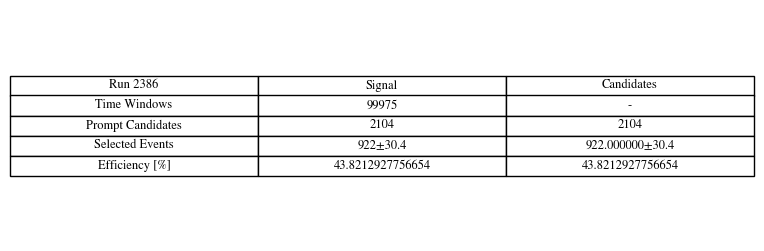

Simulated Neutrons: 5947
Expected Gammas: 2374, gamma selection efficiency 88.6267902274642%


In [1042]:
# --- Input values ---
N_prompts_sig = int(df_summary_sig["prompt_candidates"].iloc[0])

N_events_sig = np.max(df["event_number"])

N_prompts_cand = N_prompts_sig

times = (df[["event_number", "prompt_time"]]
         .drop_duplicates()
         .sort_values(["event_number", "prompt_time"]))
N_events_sel_sig = int(times.groupby("event_number")["prompt_time"].size().sum()) #df["event_number"].nunique()

N_events_cand = N_events_sel_sig


# --- Statistical uncertainties ---
# Poisson error for counts
err_N_sig = np.sqrt(N_events_sel_sig)
err_N_cand = np.sqrt(N_events_cand)

print(N_prompts_sig*100/len(truth.prompt_time_truth.unique()))

# --- Create summary table ---
results = {
    f"Run {sig_run}": [
        "Time Windows",
        "Prompt Candidates",
        "Selected Events",
        "Efficiency [%]"
    ],
    "Signal": [
        N_events_sig,
        N_prompts_sig,
        f"{N_events_sel_sig}±{err_N_sig:.1f}",
        N_events_sel_sig*100/N_prompts_sig,
    ],
    "Candidates": [
        "-",
        N_prompts_cand,
        f"{N_events_cand:1f}±{err_N_cand:.1f}",
        N_events_cand*100/N_prompts_cand
    ]
}

df_results = pd.DataFrame(results)

# Show nicely
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,3))
ax.axis('off')
tbl = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.2)

plt.show()

n_expected = 100000*270e-6*230 #n/s
gamma_expected = n_expected * 0.6

gamma_efficiency = N_prompts_cand/n_prompts_trms_gt_100

print(f'Simulated Neutrons: {n_captures}')
print(f'Expected Gammas: {n_prompts_trms_gt_100}, gamma selection efficiency {gamma_efficiency*100}%')

In [1043]:
df_out

,event_number,prompt_nhits,prompt_time,prompt_trms,prompt_tmean,delayed_time_tof,delayed_nhits,delayed_trms_tof,delayed_x,delayed_y,delayed_z,vertex_chi2,delayed_r,prompt_r,DeltaR,DeltaT,cand_id,prompt_true,delayed_true_abs,delayed_true_dt
0,108,210,68279.819523,222.036195,264.764045,74300.148008,19,1.342016,-678.488185,1059.778205,-145.195785,20.678316,1266.711442,729.725,536.986442,6.020328,0,1,1,0
1,188,107,232978.713388,237.644532,273.812151,248862.707076,41,1.395626,-199.984915,825.340513,236.596706,8.273008,881.566180,729.725,151.841180,15.883994,1,1,1,0
2,250,99,215103.476128,256.326322,292.615777,266517.696139,20,1.713678,897.952136,1175.862488,114.083284,13.552012,1483.908901,729.725,754.183901,51.414220,2,1,1,0
3,292,171,39241.446611,265.926100,305.095740,188977.985498,31,1.393510,-265.331605,876.047117,115.917908,18.605713,922.657235,729.725,192.932235,149.736539,3,1,1,0
4,533,102,71984.862564,217.807840,255.392319,124130.831257,10,0.765874,-242.513182,1336.295274,-26.856169,11.228511,1358.388367,729.725,628.663367,52.145969,4,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,99218,187,148686.480995,252.193737,266.105793,168478.659049,23,2.494409,-473.683322,1101.556181,78.308626,12.963933,1201.638111,729.725,471.913111,19.792178,917,0,1,0
918,99252,191,203499.958079,243.969264,258.593482,231244.033093,14,1.086071,-53.600773,875.459578,-277.686299,11.976316,920.006629,729.725,190.281629,27.744075,918,1,1,0
919,99771,114,95975.476707,203.337420,239.698705,147514.848877,35,2.221089,-96.521061,1603.989744,202.002839,9.153887,1619.538378,729.725,889.813378,51.539372,919,1,1,0
920,99824,234,25956.139222,219.506976,253.774769,44640.859706,34,0.807379,-57.600996,764.072001,-200.270618,6.786826,791.979935,729.725,62.254935,18.684720,920,1,1,0


In [1044]:
df_test = (df_out.loc[df_out.groupby(["event_number", "prompt_time"])["delayed_nhits"].idxmax()].reset_index(drop=True))
numb_entries = len(df_test.prompt_nhits.values)
numb_true = len(df_test[df_test.prompt_true==1].prompt_nhits.values)
print(numb_entries, numb_true, numb_true*100/numb_entries)
numb_true = len(df_test[df_test.delayed_true_abs==1].prompt_nhits.values)
print(numb_entries, numb_true, numb_true*100/numb_entries)

922 872 94.57700650759219
922 916 99.34924078091106


In [1045]:
df_test = (df_out.loc[df_out.groupby(["event_number", "prompt_time"])["DeltaT"].idxmin()].reset_index(drop=True))
numb_entries = len(df_test.prompt_nhits.values)
numb_true = len(df_test[df_test.delayed_true_abs==1].prompt_nhits.values)
print(numb_entries, numb_true, numb_true*100/numb_entries)

922 916 99.34924078091106


In [1046]:
df_test = (df_out.loc[df_out.groupby(["event_number", "prompt_time"])["DeltaR"].idxmin()].reset_index(drop=True))
numb_entries = len(df_test.prompt_nhits.values)
numb_true = len(df_test[df_test.delayed_true_abs==1].prompt_nhits.values)
print(numb_entries, numb_true, numb_true*100/numb_entries)

922 916 99.34924078091106


In [1047]:
df_test = (df_out.loc[df_out.groupby(["event_number", "prompt_time"])["vertex_chi2"].idxmin()].reset_index(drop=True))
numb_entries = len(df_test.prompt_nhits.values)
numb_true = len(df_test[df_test.delayed_true_abs==1].prompt_nhits.values)
print(numb_entries, numb_true, numb_true*100/numb_entries)

922 916 99.34924078091106


In [1048]:
df_test

,event_number,prompt_nhits,prompt_time,prompt_trms,prompt_tmean,delayed_time_tof,delayed_nhits,delayed_trms_tof,delayed_x,delayed_y,delayed_z,vertex_chi2,delayed_r,prompt_r,DeltaR,DeltaT,cand_id,prompt_true,delayed_true_abs,delayed_true_dt
0,108,210,68279.819523,222.036195,264.764045,74300.148008,19,1.342016,-678.488185,1059.778205,-145.195785,20.678316,1266.711442,729.725,536.986442,6.020328,0,1,1,0
1,188,107,232978.713388,237.644532,273.812151,248862.707076,41,1.395626,-199.984915,825.340513,236.596706,8.273008,881.566180,729.725,151.841180,15.883994,1,1,1,0
2,250,99,215103.476128,256.326322,292.615777,266517.696139,20,1.713678,897.952136,1175.862488,114.083284,13.552012,1483.908901,729.725,754.183901,51.414220,2,1,1,0
3,292,171,39241.446611,265.926100,305.095740,188977.985498,31,1.393510,-265.331605,876.047117,115.917908,18.605713,922.657235,729.725,192.932235,149.736539,3,1,1,0
4,533,102,71984.862564,217.807840,255.392319,124130.831257,10,0.765874,-242.513182,1336.295274,-26.856169,11.228511,1358.388367,729.725,628.663367,52.145969,4,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,99218,187,148686.480995,252.193737,266.105793,168478.659049,23,2.494409,-473.683322,1101.556181,78.308626,12.963933,1201.638111,729.725,471.913111,19.792178,917,0,1,0
918,99252,191,203499.958079,243.969264,258.593482,231244.033093,14,1.086071,-53.600773,875.459578,-277.686299,11.976316,920.006629,729.725,190.281629,27.744075,918,1,1,0
919,99771,114,95975.476707,203.337420,239.698705,147514.848877,35,2.221089,-96.521061,1603.989744,202.002839,9.153887,1619.538378,729.725,889.813378,51.539372,919,1,1,0
920,99824,234,25956.139222,219.506976,253.774769,44640.859706,34,0.807379,-57.600996,764.072001,-200.270618,6.786826,791.979935,729.725,62.254935,18.684720,920,1,1,0


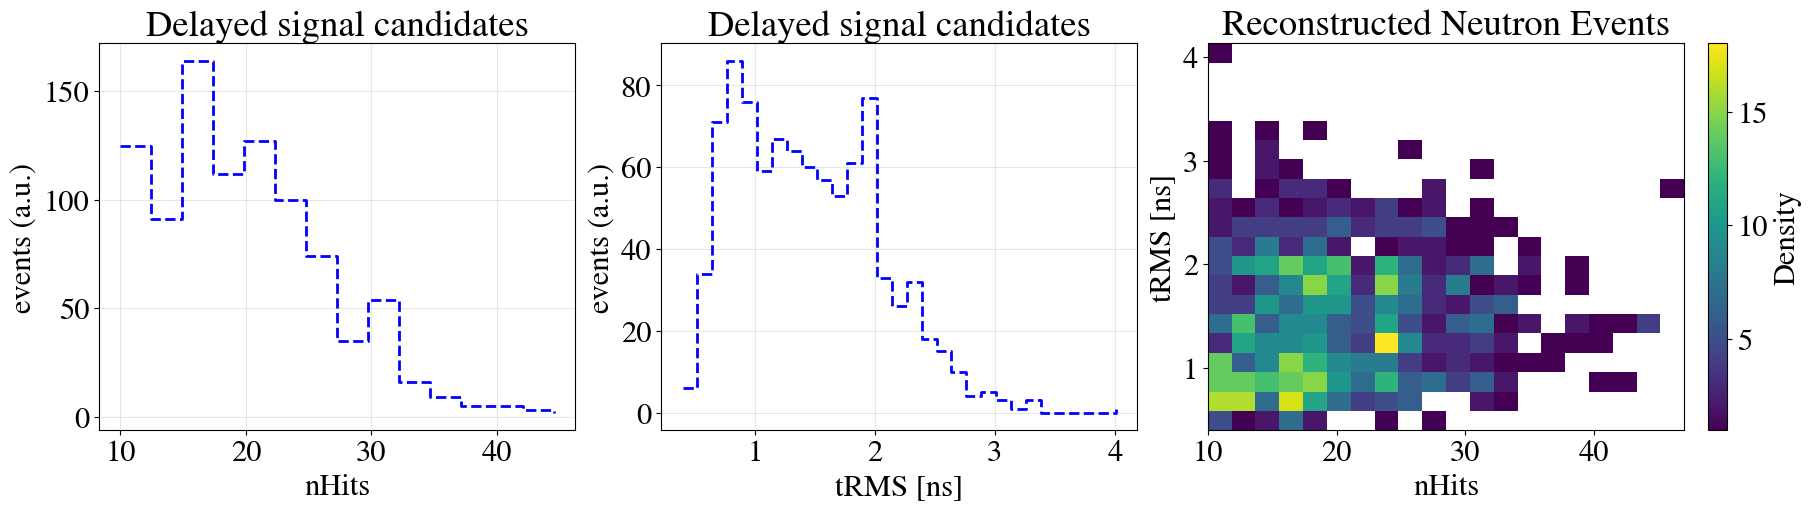

/tmp/ipykernel_3595933/2688519298.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_3595933/2688519298.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


np.float64(47.627363480436784)

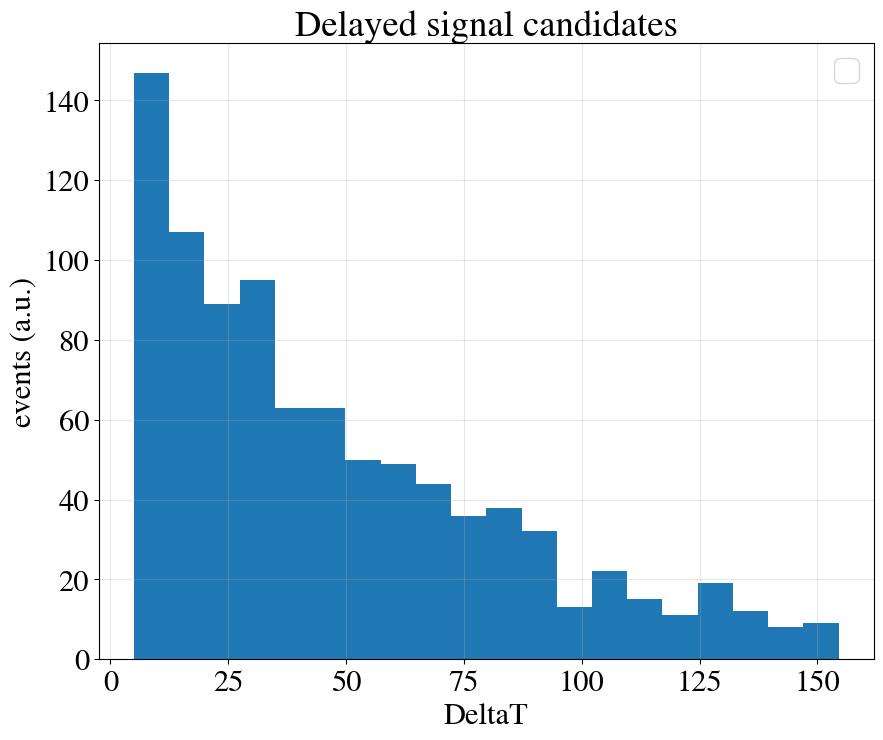

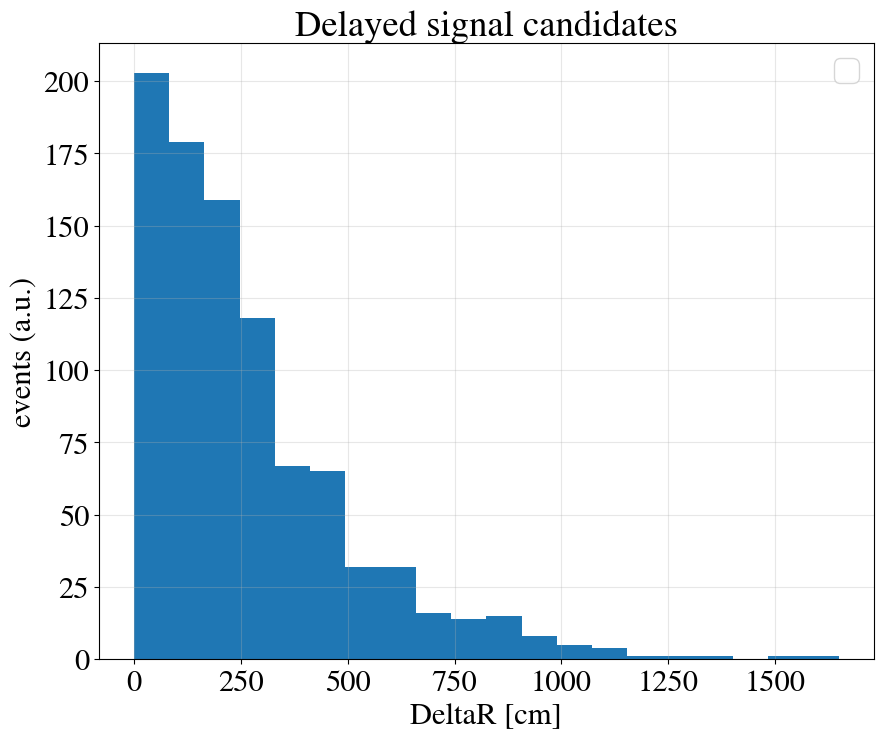

In [1049]:
#df2 = df[df.event_number == 0]

df2 = (df.loc[df.groupby(["event_number", "prompt_time"])["delayed_nhits"].idxmax()]
      .reset_index(drop=True))

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), constrained_layout=True)

# 1) nHits histogram (step)
hist_nhits, bins_nhits = np.histogram(df2.delayed_nhits.values, bins=15)
axes[0].step(
    bins_nhits[:-1], hist_nhits,
    where="post", label="candidates",
    color="blue", lw=2, linestyle="--"
)
axes[0].set_xlabel("nHits")
axes[0].set_ylabel("events (a.u.)")
axes[0].set_title("Delayed signal candidates")
axes[0].grid(alpha=0.3)

# 2) tRMS histogram (step)
hist_trms, bins_trms = np.histogram(df2.delayed_trms_tof.values, bins=30)
axes[1].step(
    bins_trms[:-1], hist_trms,
    where="post", label="candidates",
    color="blue", lw=2, linestyle="--"
)
axes[1].set_xlabel("tRMS [ns]")
axes[1].set_ylabel("events (a.u.)")
axes[1].set_title("Delayed signal candidates")
axes[1].grid(alpha=0.3)

# 3) 2D histogram
h = axes[2].hist2d(
    df2.delayed_nhits.values, df2.delayed_trms_tof.values,
    bins=20, cmin=0.0001
)
fig.colorbar(h[3], ax=axes[2], label="Density")
axes[2].set_xlabel("nHits")
axes[2].set_ylabel("tRMS [ns]")
axes[2].set_title("Reconstructed Neutron Events")

plt.show()

plt.show()

plt.figure()
plt.hist(df2.DeltaT.values, bins = 20)
#plt.step(bins_edges[:-1], hist_sig * N_events_bkg / N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('DeltaT')
plt.ylabel('events (a.u.)')
plt.title('Delayed signal candidates')
plt.legend()
plt.grid(alpha=0.3)

np.mean(df2.DeltaT.values)

plt.figure()
plt.hist(df2.DeltaR.values, bins = 20)
#plt.step(bins_edges[:-1], hist_sig * N_events_bkg / N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('DeltaR [cm]')
plt.ylabel('events (a.u.)')
plt.title('Delayed signal candidates')
plt.legend()
plt.grid(alpha=0.3)

np.mean(df2.DeltaT.values)

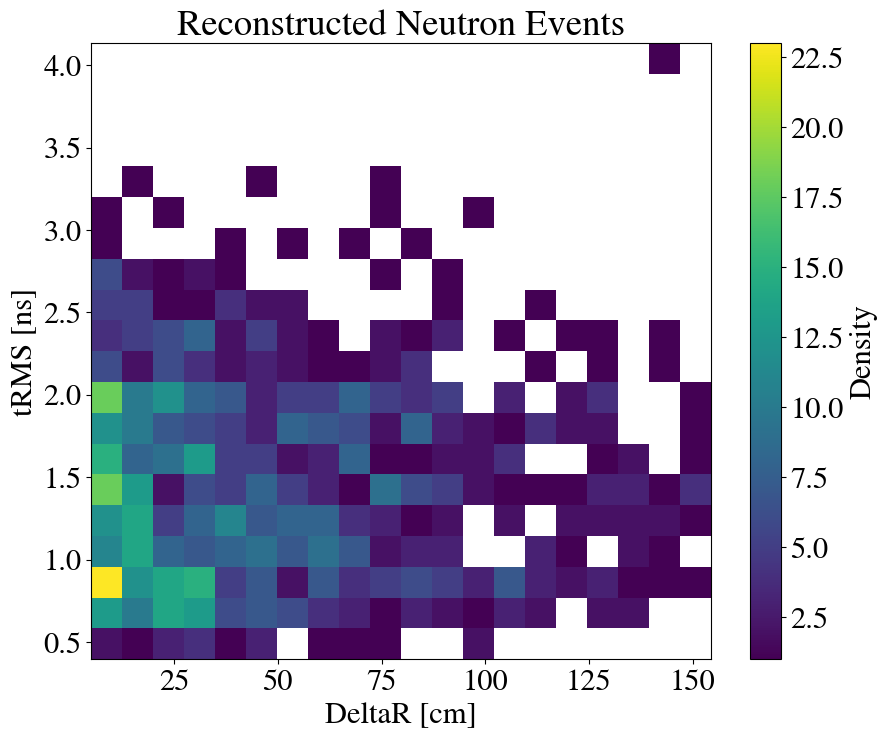

In [1050]:
plt.hist2d(df2.DeltaT.values, df2.delayed_trms_tof.values, bins=20, cmin=0.0001)
plt.colorbar(label='Density')
#plt.xlim(0, 270000)  # Set x-axis limits
#plt.ylim(0, 150)
plt.ylabel('tRMS [ns]')
plt.xlabel('DeltaR [cm]')
plt.title(f'Reconstructed Neutron Events')
plt.show()

/tmp/ipykernel_3595933/817924512.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


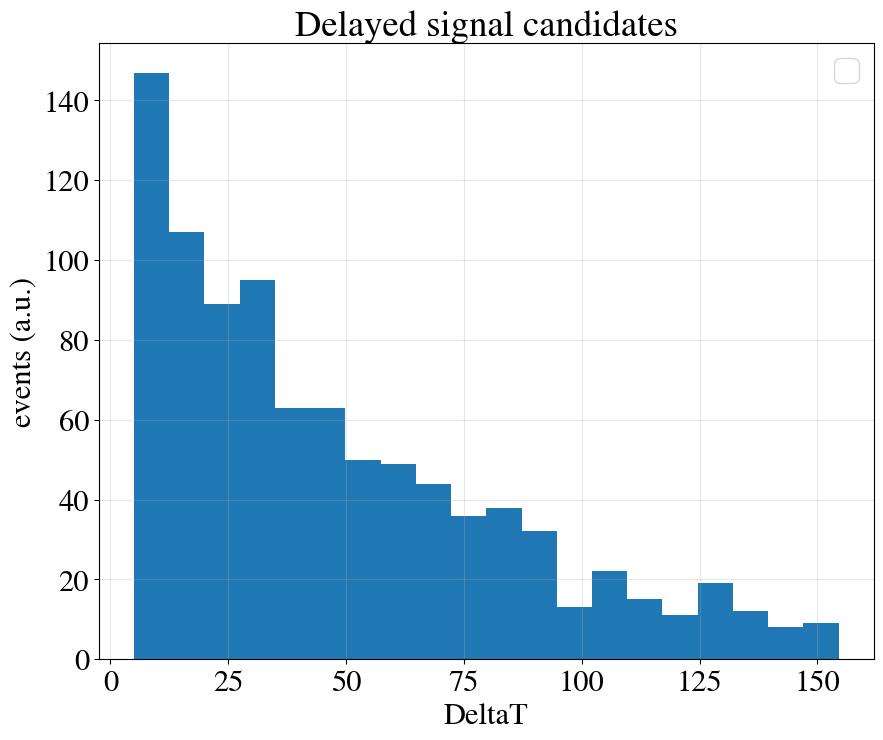

In [1051]:
plt.figure()
plt.hist(df2.DeltaT.values, bins = 20)
#plt.step(bins_edges[:-1], hist_sig * N_events_bkg / N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('DeltaT')
plt.ylabel('events (a.u.)')
plt.title('Delayed signal candidates')
plt.legend()
plt.grid(alpha=0.3)

/tmp/ipykernel_3595933/1393209992.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


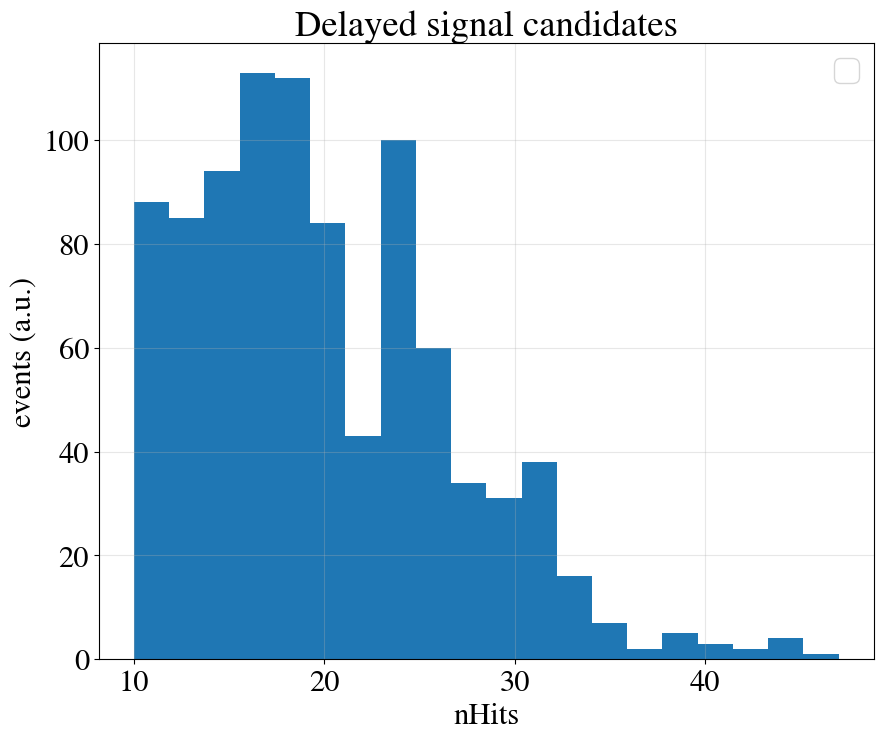

In [1052]:
plt.figure()
plt.hist(df.delayed_nhits.values, bins = 20)
#plt.step(bins_edges[:-1], hist_sig * N_events_bkg / N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('nHits')
plt.ylabel('events (a.u.)')
plt.title('Delayed signal candidates')
plt.legend()
plt.grid(alpha=0.3)

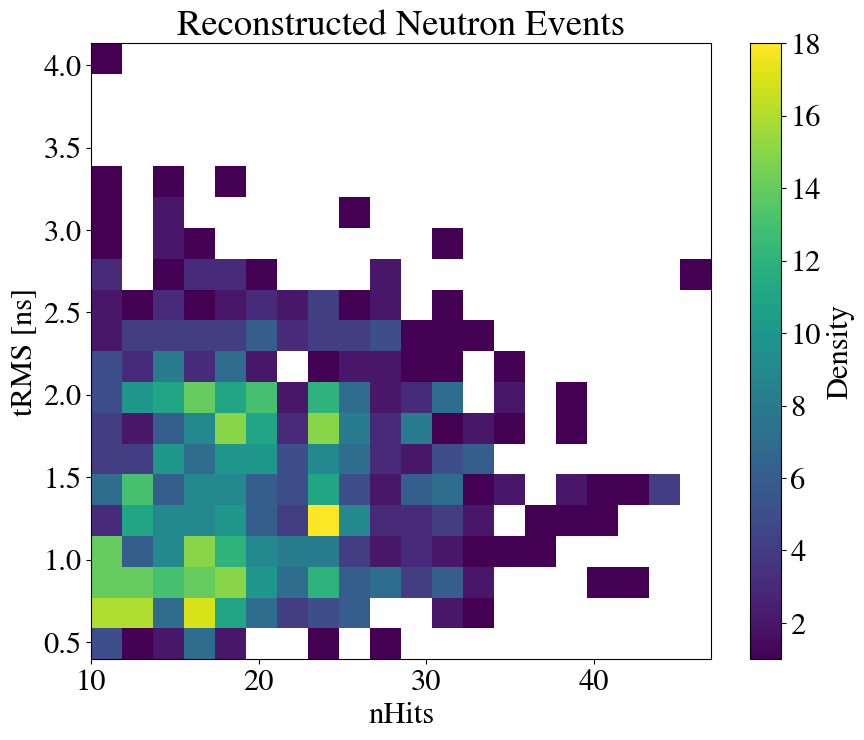

In [1053]:
plt.hist2d(df.delayed_nhits.values, df.delayed_trms_tof.values, bins=20, cmin=0.0001)
plt.colorbar(label='Density')
#plt.xlim(0, 270000)  # Set x-axis limits
#plt.ylim(0, 150)
plt.ylabel('tRMS [ns]')
plt.xlabel('nHits')
plt.title(f'Reconstructed Neutron Events')
plt.show()

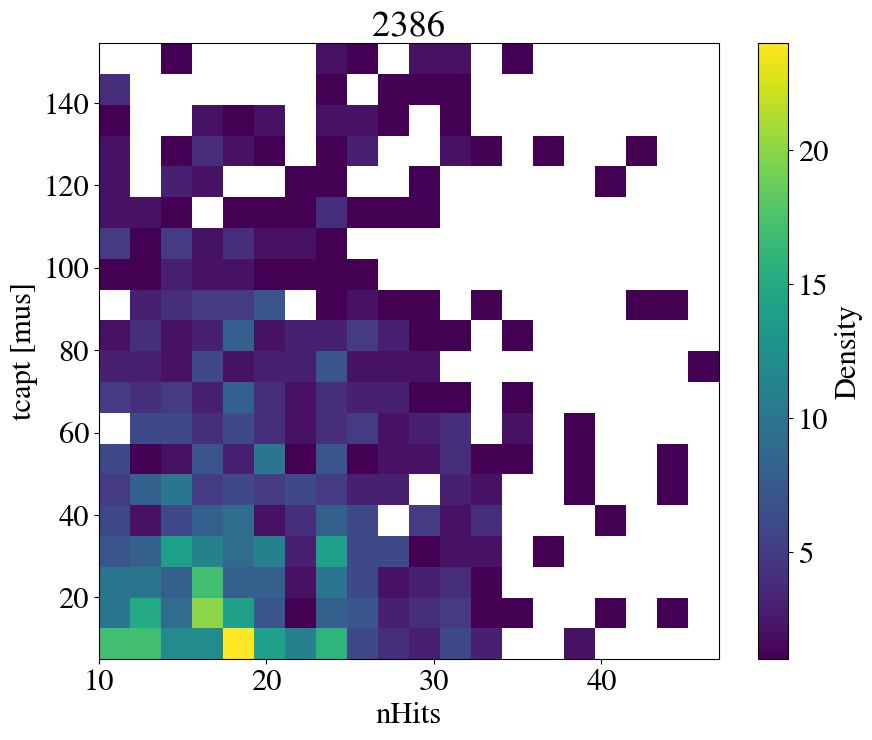

In [1054]:
plt.hist2d(df.delayed_nhits.values, df.DeltaT.values, bins=20, cmin=0.0001)
plt.colorbar(label='Density')
#plt.xlim(0, 270000)  # Set x-axis limits
#plt.ylim(0, 150)
plt.ylabel('tcapt [mus]')
plt.xlabel('nHits')
plt.title(f'{sig_run}')
plt.show()

In [1055]:
df[df.event_number == 0]

,event_number,prompt_nhits,prompt_time,prompt_trms,prompt_tmean,delayed_time_tof,delayed_nhits,delayed_trms_tof,delayed_x,delayed_y,delayed_z,vertex_chi2,delayed_r,prompt_r,DeltaR,DeltaT


/tmp/ipykernel_3595933/2801877625.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


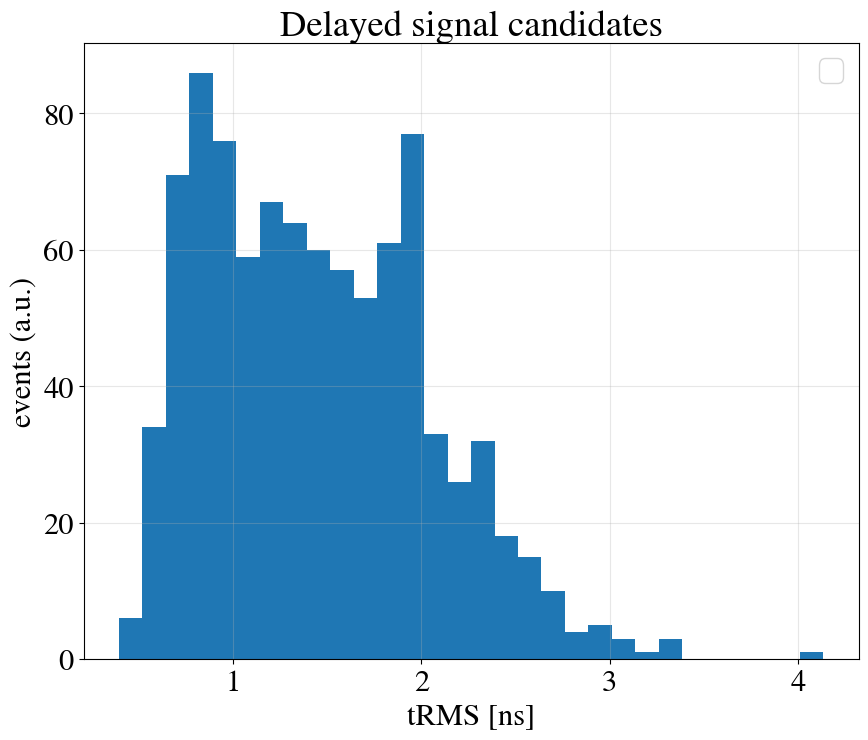

In [1056]:
plt.figure()
plt.hist(df.delayed_trms_tof.values, bins = 30)
#plt.step(bins_edges[:-1], hist_sig * N_events_bkg / N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('tRMS [ns]')
plt.ylabel('events (a.u.)')
plt.title('Delayed signal candidates')
plt.legend()
plt.grid(alpha=0.3)

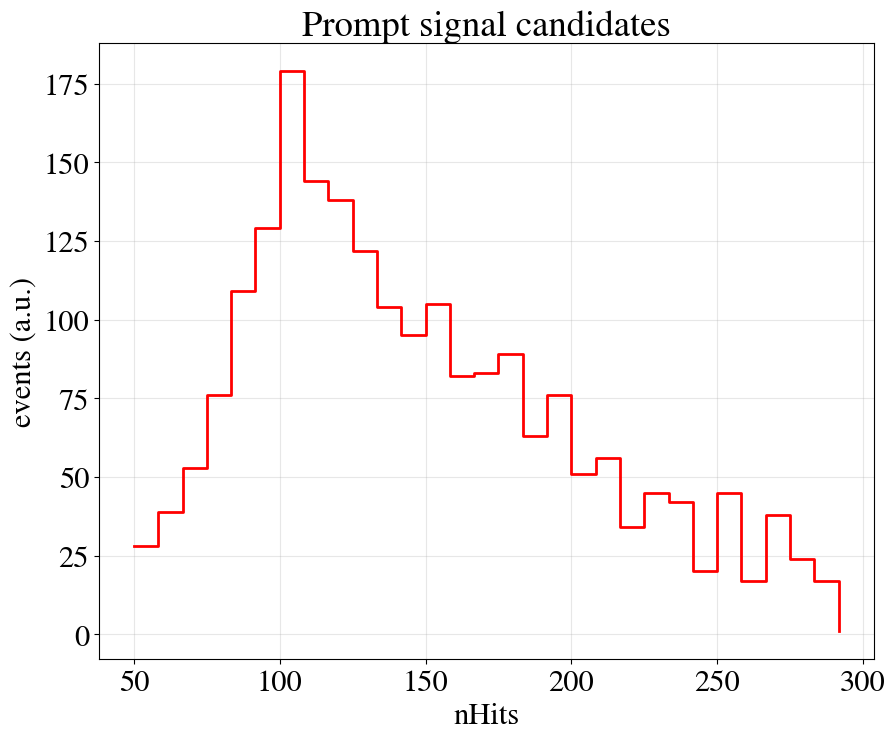

In [1057]:
prompt_nhits = df_gamma.prompt_nhits.values

hist_sig, bins_edges = np.histogram(prompt_nhits, bins = 30, range=(50, 300))

plt.figure()
plt.step(bins_edges[:-1], hist_sig, where='post', linewidth=2, color='red', label=f'MC')

plt.xlabel('nHits')
plt.ylabel('events (a.u.)')
plt.title('Prompt signal candidates')
#plt.yscale('log') 
#plt.legend()
plt.grid(alpha=0.3)

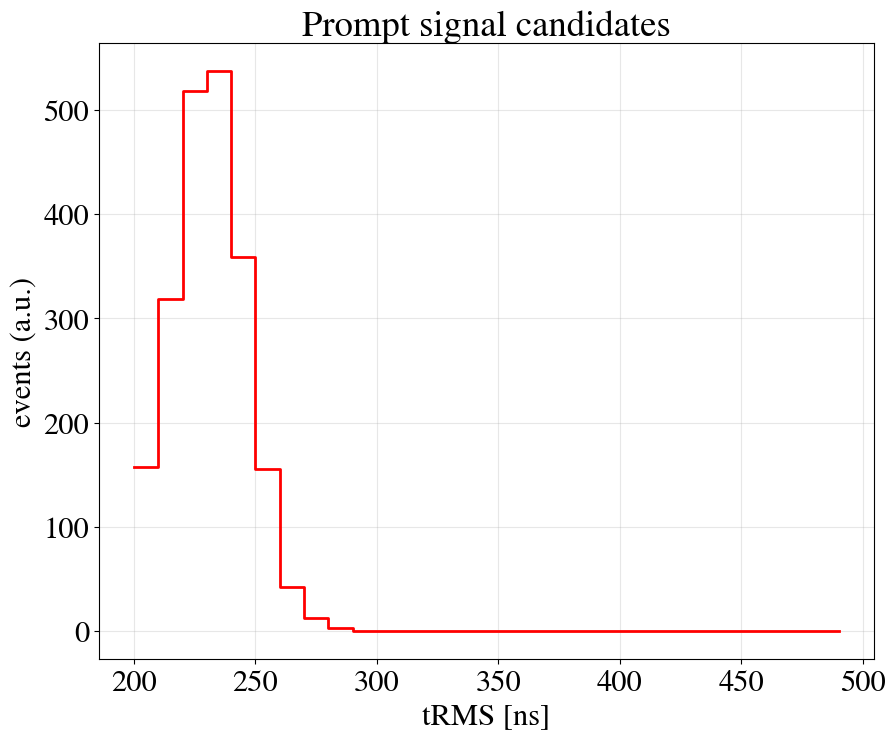

In [1058]:
prompt_nhits = df_gamma.prompt_trms.values

hist_sig, bins_edges = np.histogram(prompt_nhits, bins = 30, range=(200, 500))

plt.figure()
plt.step(bins_edges[:-1], hist_sig, where='post', linewidth=2, color='red', label=f'MC')

plt.xlabel('tRMS [ns]')
plt.ylabel('events (a.u.)')
plt.title('Prompt signal candidates')
#plt.yscale('log') 
#plt.legend()
plt.grid(alpha=0.3)

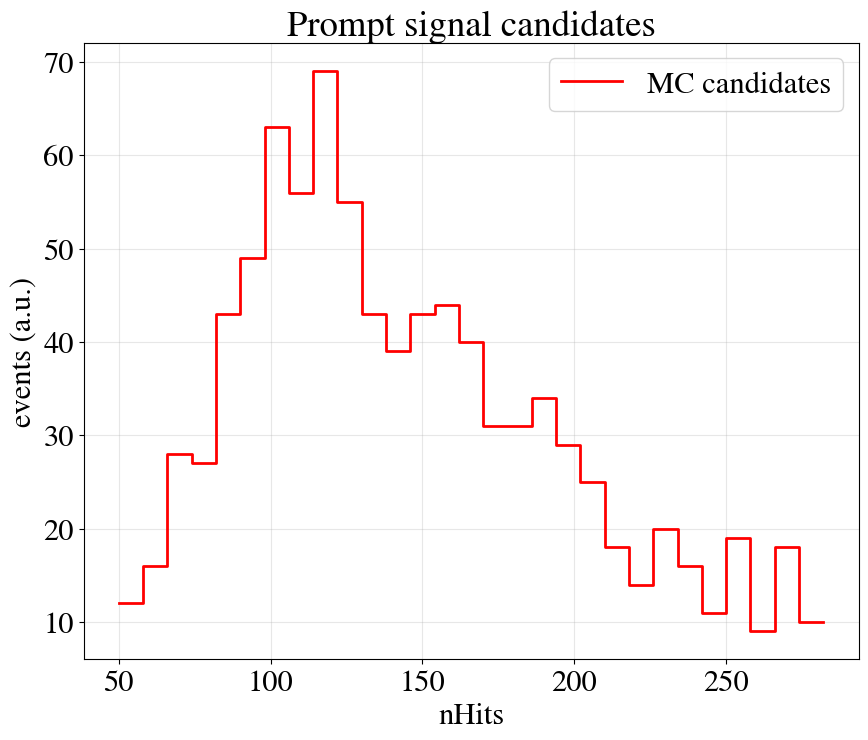

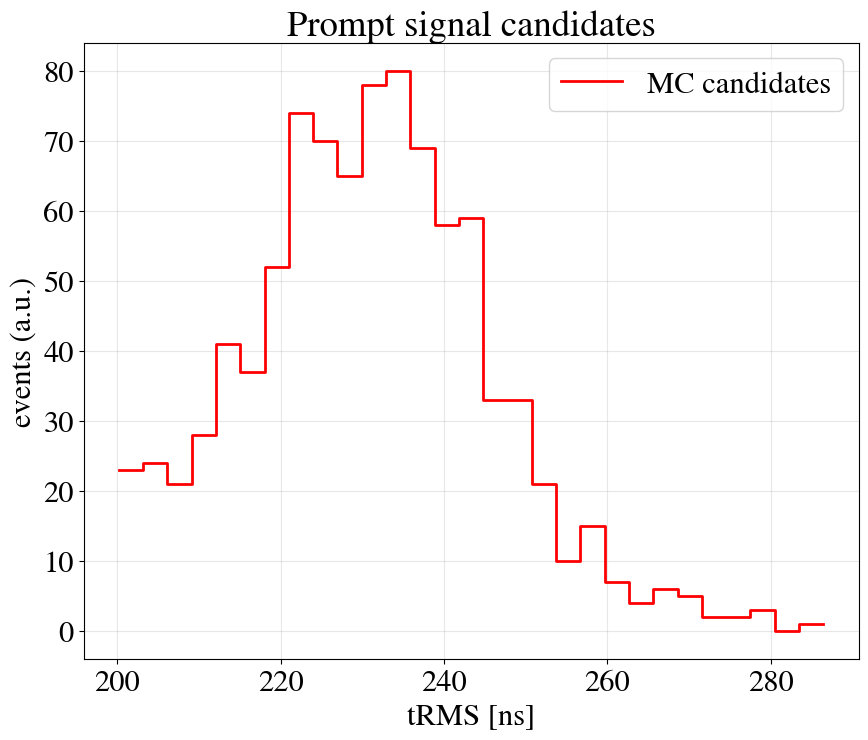

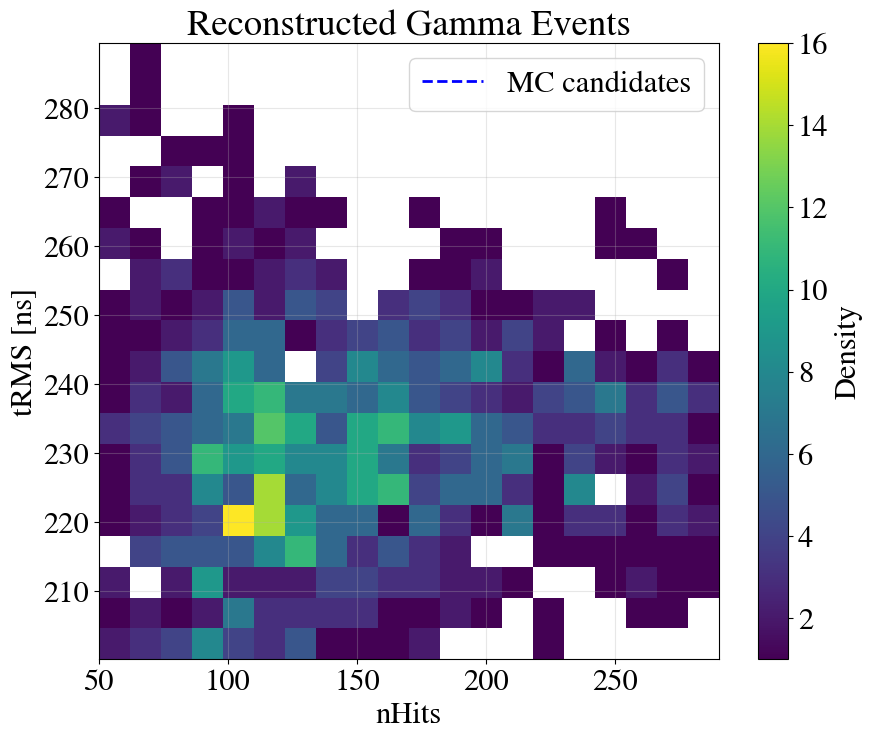

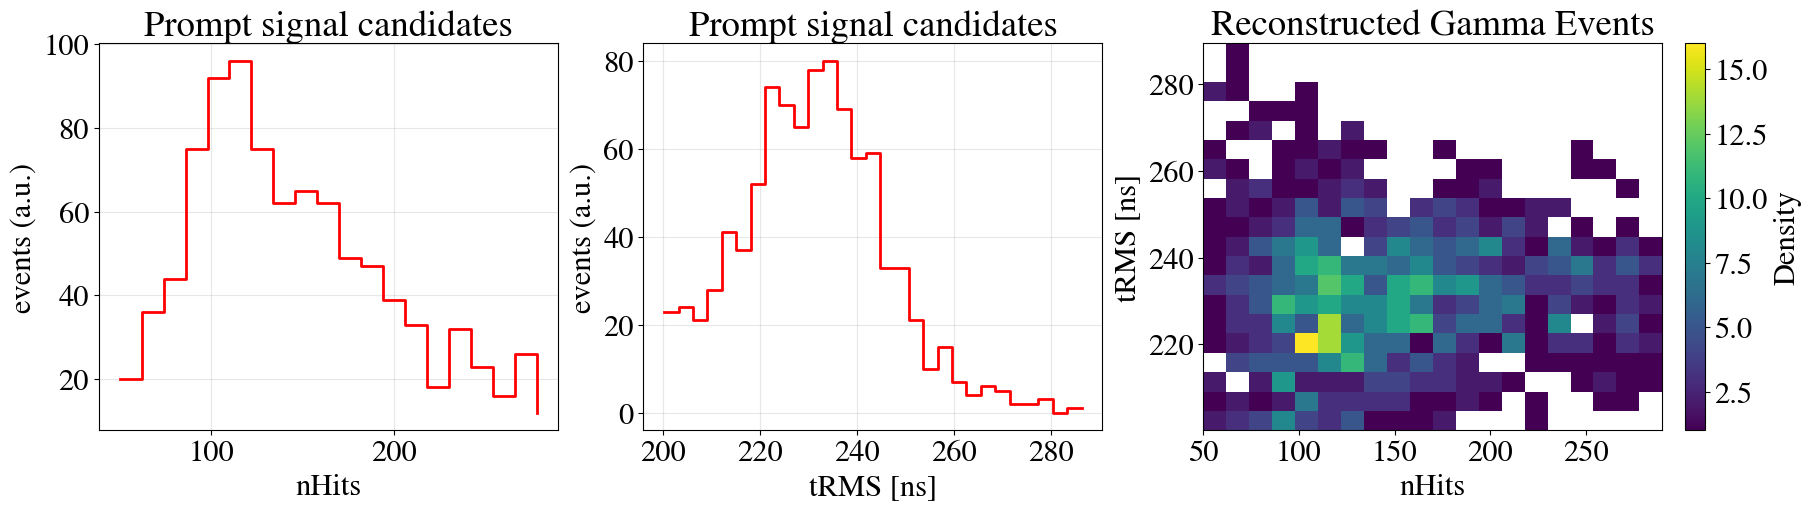

In [1059]:
hist, bins_edges = np.histogram(df.prompt_nhits.values, bins = 30)

plt.figure()
plt.step(bins_edges[:-1], hist, where='post', label=f'MC candidates', color='red', lw=2, linestyle = '-')
#plt.step(bins_edges[:-1], hist_sig * N_events_bkg / N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('nHits')
plt.ylabel('events (a.u.)')
plt.title('Prompt signal candidates')
plt.legend()
plt.grid(alpha=0.3)


hist, bins_edges = np.histogram(df.prompt_trms.values, bins = 30)

plt.figure()
plt.step(bins_edges[:-1], hist, where='post', label=f'MC candidates', color='red', lw=2, linestyle = '-')
#plt.step(bins_edges[:-1], hist_sig * N_events_bkg / N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('tRMS [ns]')
plt.ylabel('events (a.u.)')
plt.title('Prompt signal candidates')
plt.legend()
plt.grid(alpha=0.3)



hist, bins_edges = np.histogram(df.prompt_trms.values, bins = 30)
plt.figure()
plt.step(bins_edges[:-1], hist, where='post', label=f'MC candidates', color='blue', lw=2, linestyle = '--')
#plt.step(bins_edges[:-1], hist_sig * N_events_bkg / N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('tRMS [ns]')
plt.ylabel('events (a.u.)')
plt.title('Prompt signal candidates')
plt.legend()
plt.grid(alpha=0.3)

plt.hist2d(df.prompt_nhits.values, df.prompt_trms.values, bins=20, cmin=0.0001)
plt.colorbar(label='Density')
#plt.xlim(0, 270000)  # Set x-axis limits
#plt.ylim(0, 150)
plt.ylabel('tRMS [ns]')
plt.xlabel('nHits')
plt.title(f'Reconstructed Gamma Events')
plt.show()

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), constrained_layout=True)

# 1) nHits histogram (step)
hist_nhits, bins_nhits = np.histogram(df.prompt_nhits.values, bins=20)
axes[0].step(
    bins_nhits[:-1], hist_nhits,
    where="post", label="candidates",
    color="red", lw=2, linestyle="-"
)
axes[0].set_xlabel("nHits")
axes[0].set_ylabel("events (a.u.)")
axes[0].set_title("Prompt signal candidates")
axes[0].grid(alpha=0.3)

# 2) tRMS histogram (step)
hist_trms, bins_trms = np.histogram(df.prompt_trms.values, bins=30)
axes[1].step(
    bins_trms[:-1], hist_trms,
    where="post", label="MC candidates",
    color="red", lw=2, linestyle="-"
)
axes[1].set_xlabel("tRMS [ns]")
axes[1].set_ylabel("events (a.u.)")
axes[1].set_title("Prompt signal candidates")
axes[1].grid(alpha=0.3)

# 3) 2D histogram
h = axes[2].hist2d(
    df.prompt_nhits.values, df.prompt_trms.values,
    bins=20, cmin=0.0001
)
fig.colorbar(h[3], ax=axes[2], label="Density")
axes[2].set_xlabel("nHits")
axes[2].set_ylabel("tRMS [ns]")
axes[2].set_title("Reconstructed Gamma Events")

plt.show()

plt.show()

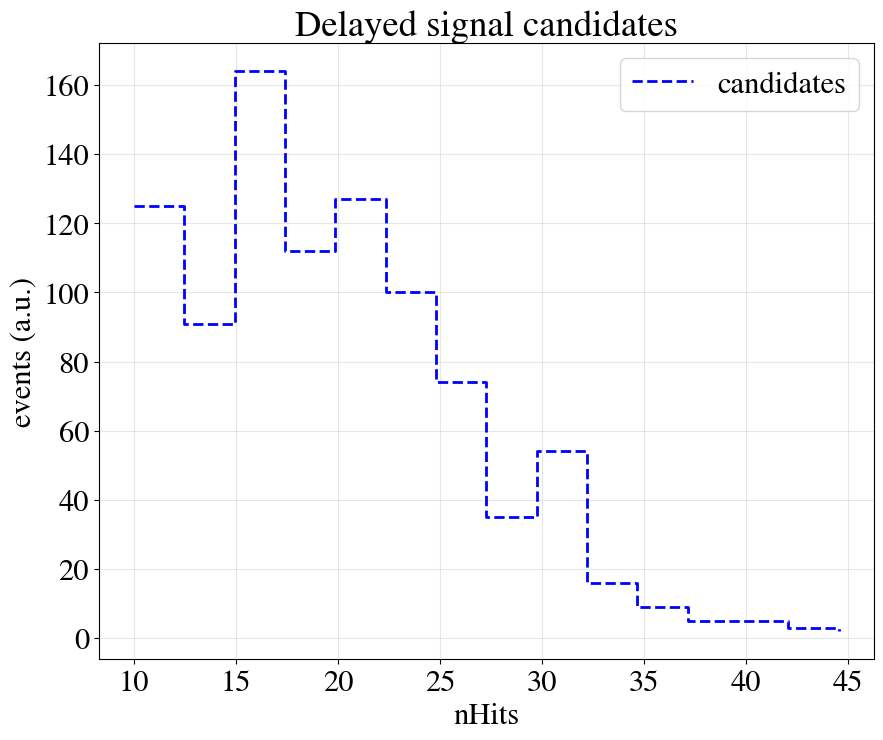

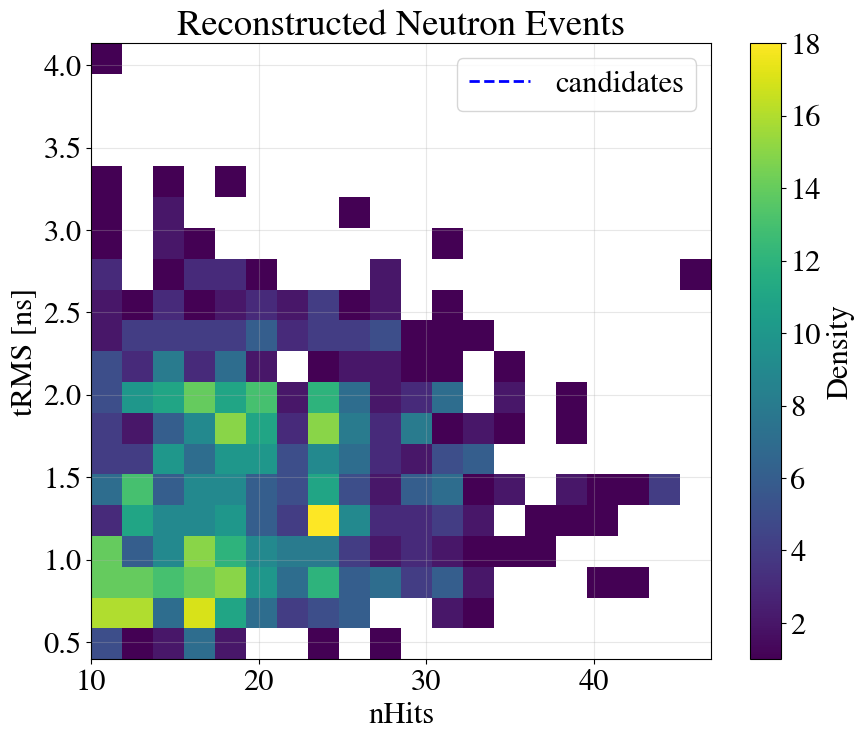

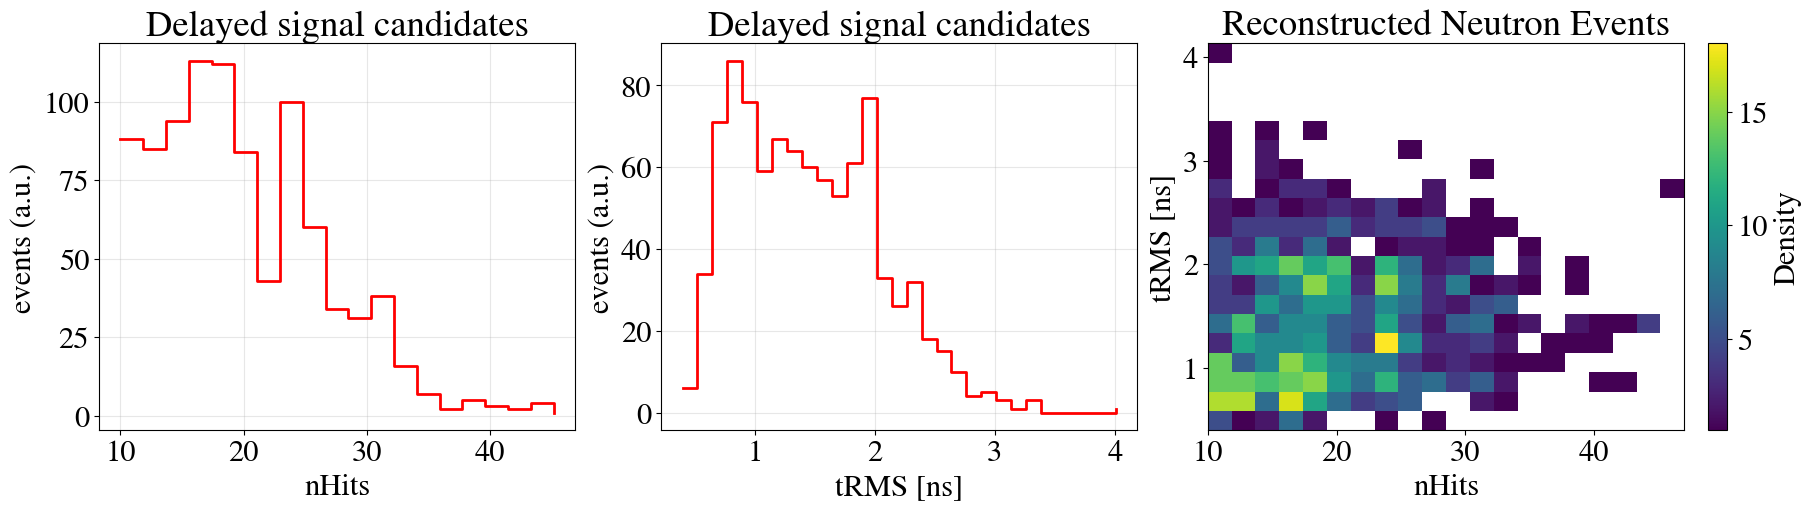

In [1060]:
hist, bins_edges = np.histogram(df.delayed_nhits.values, bins = 15)

plt.figure()
plt.step(bins_edges[:-1], hist, where='post', label=f'candidates', color='blue', lw=2, linestyle = '--')
#plt.step(bins_edges[:-1], hist_sig * N_events_bkg / N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('nHits')
plt.ylabel('events (a.u.)')
plt.title('Delayed signal candidates')
plt.legend()
plt.grid(alpha=0.3)


hist, bins_edges = np.histogram(df.delayed_trms_tof.values, bins = 30)
plt.figure()
plt.step(bins_edges[:-1], hist, where='post', label=f'candidates', color='blue', lw=2, linestyle = '--')
#plt.step(bins_edges[:-1], hist_sig * N_events_bkg / N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('tRMS [ns]')
plt.ylabel('events (a.u.)')
plt.title('Delayed signal candidates')
plt.legend()
plt.grid(alpha=0.3)

plt.hist2d(df.delayed_nhits.values, df.delayed_trms_tof.values, bins=20, cmin=0.0001)
plt.colorbar(label='Density')
#plt.xlim(0, 270000)  # Set x-axis limits
#plt.ylim(0, 150)
plt.ylabel('tRMS [ns]')
plt.xlabel('nHits')
plt.title(f'Reconstructed Neutron Events')
plt.show()

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), constrained_layout=True)

# 1) nHits histogram (step)
hist_nhits, bins_nhits = np.histogram(df.delayed_nhits.values, bins=20)
axes[0].step(
    bins_nhits[:-1], hist_nhits,
    where="post", label="candidates",
    color="red", lw=2, linestyle="-"
)
axes[0].set_xlabel("nHits")
axes[0].set_ylabel("events (a.u.)")
axes[0].set_title("Delayed signal candidates")
axes[0].grid(alpha=0.3)

# 2) tRMS histogram (step)
hist_trms, bins_trms = np.histogram(df.delayed_trms_tof.values, bins=30)
axes[1].step(
    bins_trms[:-1], hist_trms,
    where="post", label="candidates",
    color="red", lw=2, linestyle="-"
)
axes[1].set_xlabel("tRMS [ns]")
axes[1].set_ylabel("events (a.u.)")
axes[1].set_title("Delayed signal candidates")
axes[1].grid(alpha=0.3)

# 3) 2D histogram
h = axes[2].hist2d(
    df.delayed_nhits.values, df.delayed_trms_tof.values,
    bins=20, cmin=0.0001
)
fig.colorbar(h[3], ax=axes[2], label="Density")
axes[2].set_xlabel("nHits")
axes[2].set_ylabel("tRMS [ns]")
axes[2].set_title("Reconstructed Neutron Events")

plt.show()

plt.show()

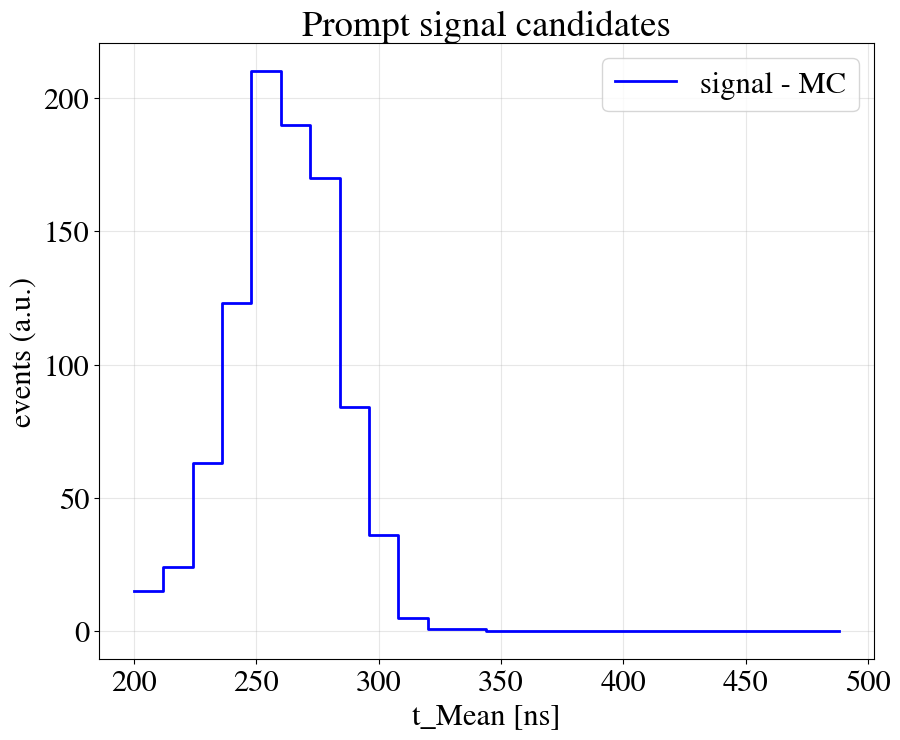

In [1061]:
prompt_nhits = df.prompt_tmean.unique()

hist, bins_edges = np.histogram(prompt_nhits, bins=25, range=(200, 500))

plt.figure()
plt.step(bins_edges[:-1], hist , where='post', label=f'signal - MC', color='blue', lw=2)
plt.xlabel('t_Mean [ns]')
plt.ylabel('events (a.u.)')
plt.title('Prompt signal candidates')
plt.legend()
plt.grid(alpha=0.3)

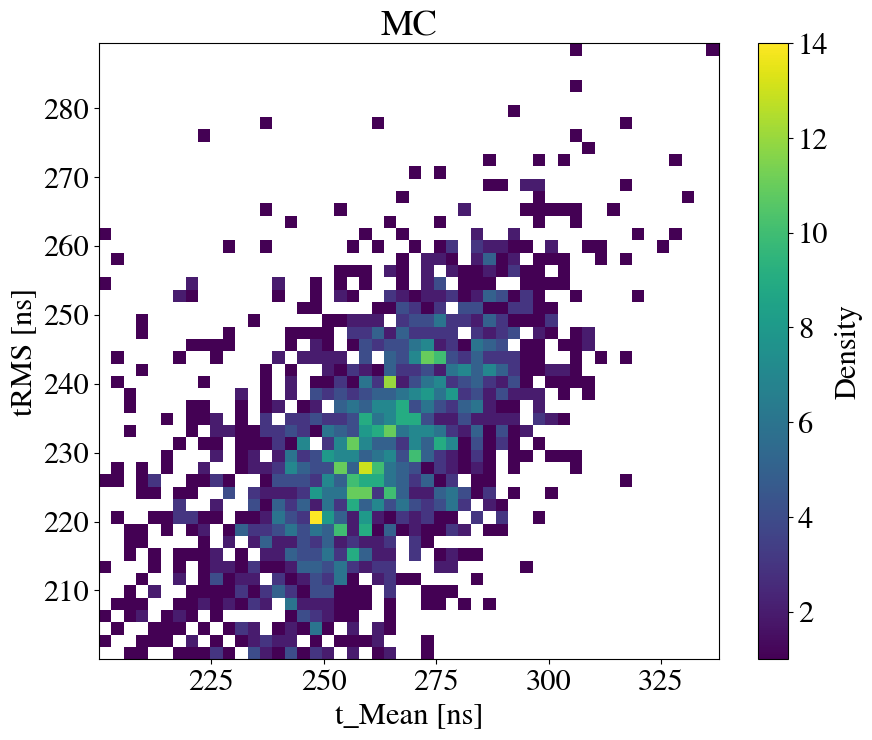

In [1062]:
plt.hist2d(df_gamma.prompt_tmean.values, df_gamma.prompt_trms.values, bins=50, cmin=0.0001)
plt.colorbar(label='Density')
#plt.xlim(0, 270000)  # Set x-axis limits
#plt.ylim(0, 150)
plt.xlabel('t_Mean [ns]')
plt.ylabel('tRMS [ns]')
plt.title('MC')
plt.show()

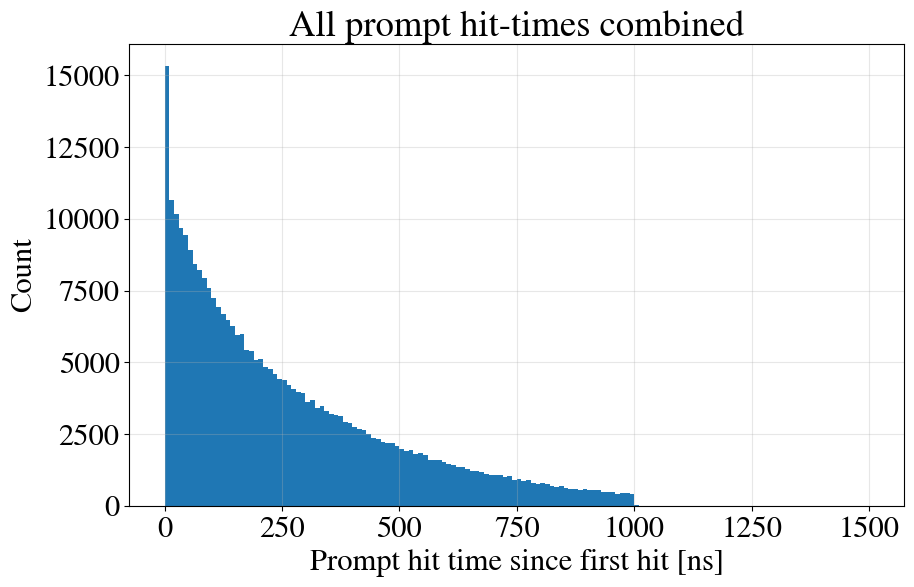

In [1063]:
events = df_gamma["prompt_times_raw"].values

def to_numeric_array(ev):
    # already array-like numeric
    if isinstance(ev, np.ndarray):
        return ev.astype(float)
    if isinstance(ev, (list, tuple)):
        return np.asarray(ev, dtype=float)

    # string case: "[1.2, 3.4, 5.6]"
    if isinstance(ev, str):
        ev = ev.strip()
        try:
            return np.asarray(ast.literal_eval(ev), dtype=float)
        except Exception:
            # fallback for badly formatted whitespace-separated strings
            ev = ev.strip("[]")
            return np.fromstring(ev, sep=",", dtype=float)

    # final fallback
    return np.asarray(ev, dtype=float)

shifted = []
for ev in events:
    arr = to_numeric_array(ev)
    if arr.size == 0:
        continue
    arr = np.sort(arr)          # optional but recommended
    arr = arr - arr[0]          # set first hit to 0
    shifted.append(arr)

all_shifted_hit_times = np.concatenate(shifted)

plt.figure(figsize=(10, 6))
plt.hist(all_shifted_hit_times, bins=150, range=(0, 1500))
plt.xlabel("Prompt hit time since first hit [ns]")
plt.ylabel("Count")
plt.title("All prompt hit-times combined")
plt.grid(alpha=0.3)
plt.show()

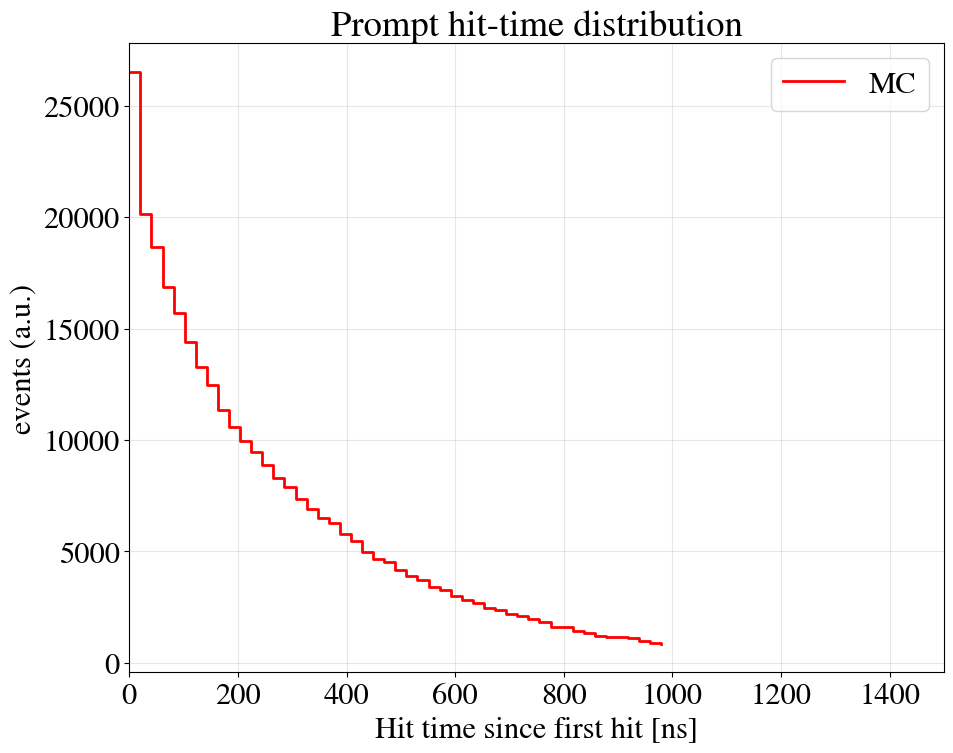

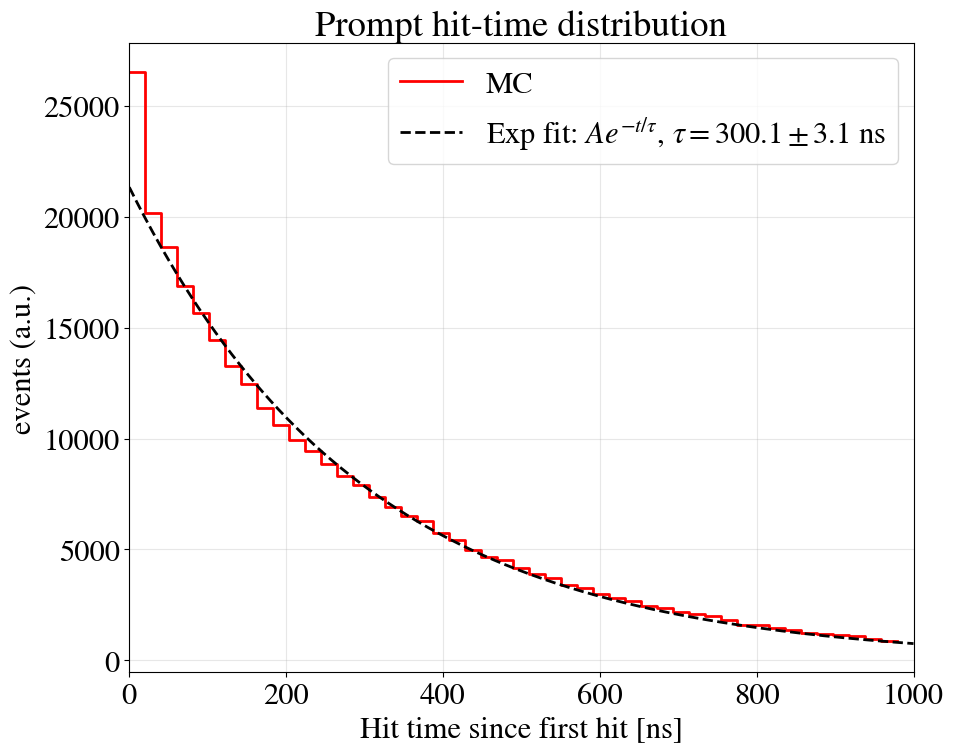

A   = 21319.817 ± 164.755
tau = 300.091 ± 3.121 ns


In [1064]:
def to_numeric_array(ev):
    if isinstance(ev, np.ndarray):
        return ev.astype(float)
    if isinstance(ev, (list, tuple)):
        return np.asarray(ev, dtype=float)
    if isinstance(ev, str):
        ev = ev.strip()
        try:
            return np.asarray(ast.literal_eval(ev), dtype=float)
        except Exception:
            ev = ev.strip("[]")
            return np.fromstring(ev, sep=",", dtype=float)
    return np.asarray(ev, dtype=float)

def get_shifted_times(df, col="prompt_times_raw", tmax=1000, sort_hits=True):
    shifted_all = []

    for ev in df[col].dropna().values:
        arr = to_numeric_array(ev)
        if arr.size == 0:
            continue

        if sort_hits:
            arr = np.sort(arr)

        arr = arr - arr[0]   # first hit -> 0

        # keep only hits inside prompt window
        arr = arr[(arr >= 0) & (arr <= tmax)]

        if arr.size > 0:
            shifted_all.append(arr)

    if not shifted_all:
        return np.array([])

    return np.concatenate(shifted_all)

# Get combined shifted hit times
sig_times = get_shifted_times(df_gamma, col="prompt_times_raw", tmax=1000)

# Common binning
bins = np.linspace(0, 1000, 50)   # 25 bins of 60 ns each

sig_counts, edges = np.histogram(sig_times, bins=bins)

# Plot
plt.figure()

plt.step(edges[:-1], sig_counts, where='post',
         color='red', linewidth=2,
         label='MC')

plt.xlabel('Hit time since first hit [ns]')
plt.ylabel('events (a.u.)')
plt.title('Prompt hit-time distribution')
plt.xlim(0, 1500)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


def expo(t, A, tau):
    return A * np.exp(-t / tau)

bin_centers = 0.5 * (edges[:-1] + edges[1:])
fit_mask = (bin_centers >= 30) & (bin_centers <= 1500) & (sig_counts > 0)

x_fit = bin_centers[fit_mask]
y_fit = sig_counts[fit_mask]

# initial guesses
p0 = [y_fit.max(), 300]

# fit
popt, pcov = curve_fit(expo, x_fit, y_fit, p0=p0)
A_fit, tau_fit = popt
A_err, tau_err = np.sqrt(np.diag(pcov))

# smooth curve for plotting
x_smooth = np.linspace(0, 1000, 500)
y_smooth = expo(x_smooth, A_fit, tau_fit)

# Plot
plt.figure()

plt.step(edges[:-1], sig_counts, where='post',
         color='red', linewidth=2,
         label='MC')

plt.plot(x_smooth, y_smooth,
         color='black', linestyle='--', linewidth=2,
         label=fr'Exp fit: $A e^{{-t/\tau}}$, $\tau = {tau_fit:.1f} \pm {tau_err:.1f}$ ns')

plt.xlabel('Hit time since first hit [ns]')
plt.ylabel('events (a.u.)')
plt.title('Prompt hit-time distribution')
plt.xlim(0, 1000)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"A   = {A_fit:.3f} ± {A_err:.3f}")
print(f"tau = {tau_fit:.3f} ± {tau_err:.3f} ns")

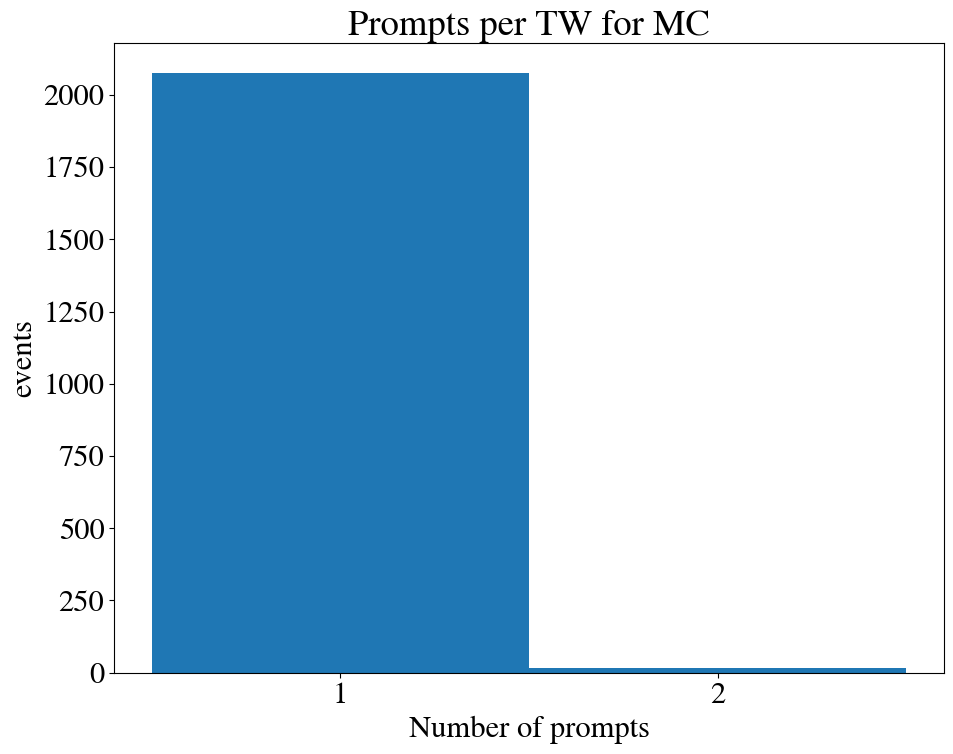

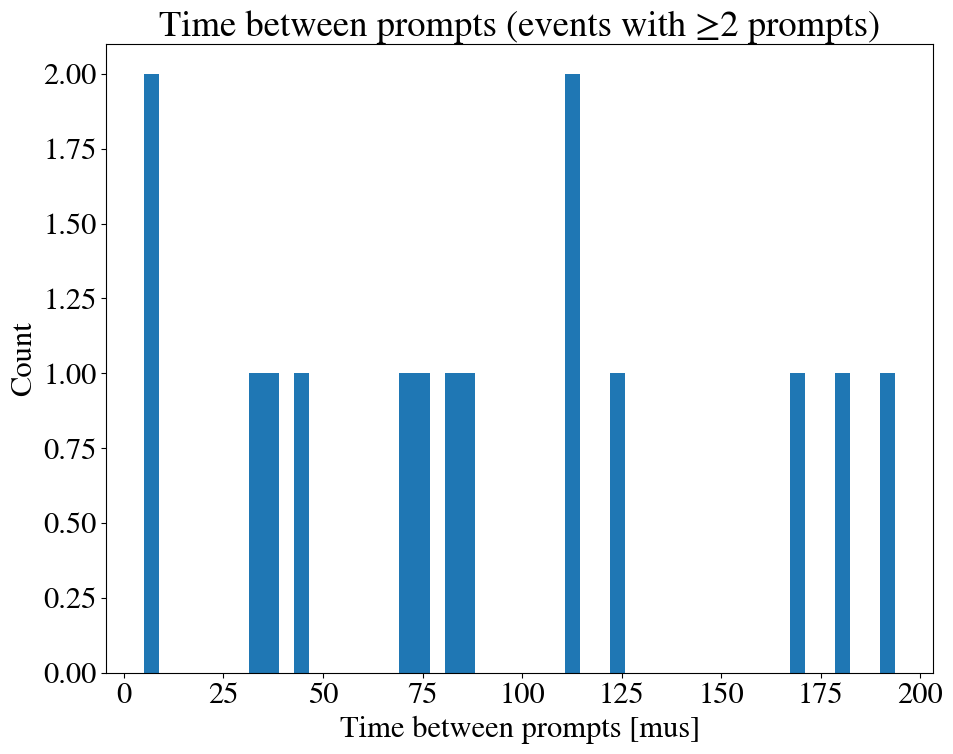

In [1065]:
df2 = df_gamma.copy()

# use df_gamma["prompt_ti"] instead of ["prompt_time"]
df2["prompt_ti"] = pd.to_numeric(df2["prompt_ti"], errors="coerce")
df2 = df2.dropna(subset=["event_number", "prompt_ti"])

# use unique prompt times per event (common for “how many prompts”)
times = (df2[["event_number", "prompt_ti"]]
         .drop_duplicates()
         .sort_values(["event_number", "prompt_ti"]))

# --- Plot 1: number of prompts per event ---
prompts_per_event = times.groupby("event_number")["prompt_ti"].size()

fig, ax = plt.subplots()
bins1 = np.arange(1, prompts_per_event.max() + 2) - 0.5
ax.hist(prompts_per_event, bins=bins1, lw=2)

ax.set_xlabel("Number of prompts")
ax.set_ylabel("events")
ax.set_title(f"Prompts per TW for MC")
ax.set_xticks(np.arange(1, prompts_per_event.max() + 1))
fig.tight_layout()

# --- Plot 2: time between prompts (events with >= 2 prompts) ---
times = times.copy()
times["dt"] = times.groupby("event_number")["prompt_ti"].diff()

# if prompt_ti is in ns/ps/etc, keep your scaling consistent.
# This mirrors your original: dt/1000
dt = times.loc[times["dt"].notna(), "dt"] / 1000

fig, ax = plt.subplots()
ax.hist(dt, bins=50)

ax.set_xlabel("Time between prompts [mus]")
ax.set_ylabel("Count")
ax.set_title("Time between prompts (events with ≥2 prompts)")
fig.tight_layout()

plt.show()

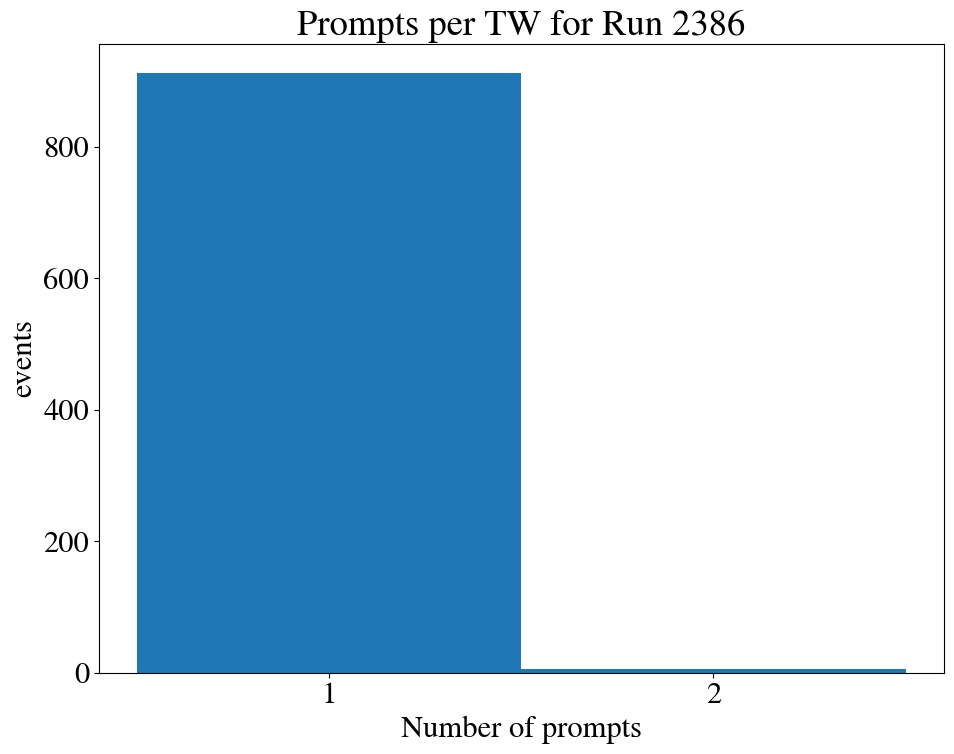

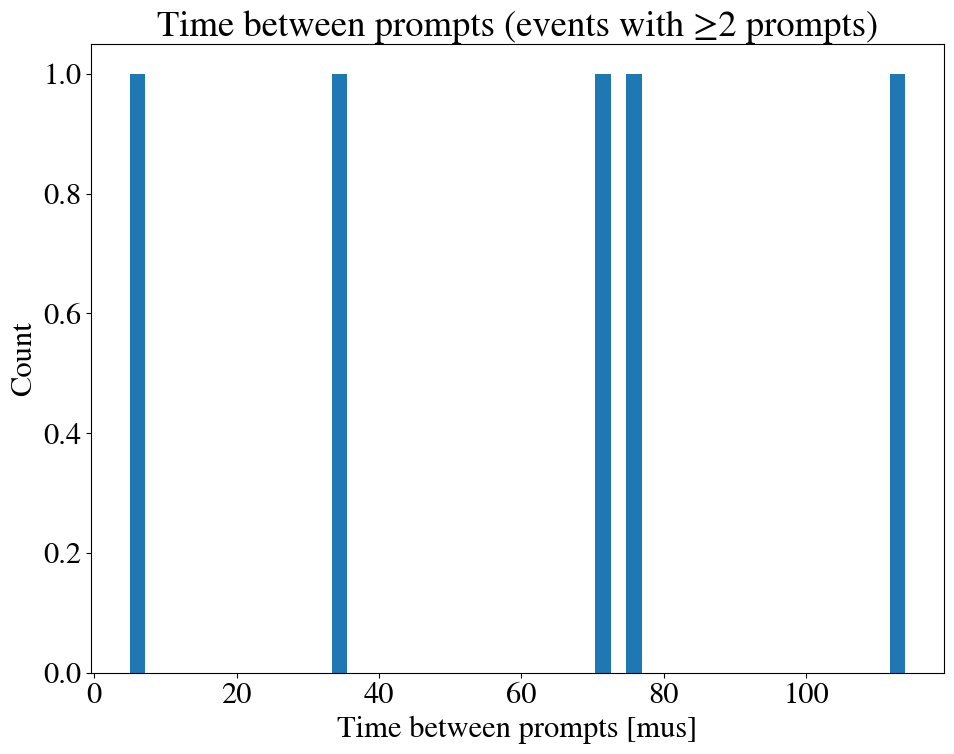

In [1066]:
df2 = df.copy()

df2["prompt_time"] = pd.to_numeric(df2["prompt_time"], errors="coerce")
df2 = df2.dropna(subset=["event_number", "prompt_time"])

# use unique prompt times per event (common for “how many prompts”)
times = (df2[["event_number", "prompt_time"]]
         .drop_duplicates()
         .sort_values(["event_number", "prompt_time"]))

# --- Plot 1: number of prompts per event ---
prompts_per_event = times.groupby("event_number")["prompt_time"].size()

fig, ax = plt.subplots()
bins1 = np.arange(1, prompts_per_event.max() + 2) - 0.5
ax.hist(prompts_per_event, bins=bins1, lw=2)

ax.set_xlabel("Number of prompts")
ax.set_ylabel("events")
ax.set_title(f"Prompts per TW for Run {sig_run}")
ax.set_xticks(np.arange(1, prompts_per_event.max() + 1))
fig.tight_layout()

# --- Plot 2: time between prompts (events with >= 2 prompts) ---
times = times.copy()
times["dt"] = times.groupby("event_number")["prompt_time"].diff()
dt = times.loc[times["dt"].notna(), "dt"]/1000

fig, ax = plt.subplots()
ax.hist(dt, bins=50)

ax.set_xlabel("Time between prompts [mus]")
ax.set_ylabel("Count")
ax.set_title("Time between prompts (events with ≥2 prompts)")
fig.tight_layout()

plt.show()

In [1067]:
df2 = df.copy()
df2["prompt_time"] = pd.to_numeric(df2["prompt_time"], errors="coerce")
df2 = df2.dropna(subset=["event_number", "prompt_time"])

# unique prompt times per TW (event)
times = (df2[["event_number", "prompt_time"]]
         .drop_duplicates())

# prompts per TW
prompts_per_event = times.groupby("event_number")["prompt_time"].size()

total_candidates = int(prompts_per_event.sum())

# how many TWs have 1,2,3,... prompts
tw_by_nprompts = (prompts_per_event
                  .value_counts()
                  .sort_index()
                  .rename_axis("n_prompts")
                  .rename("n_TW"))

print(total_candidates)
print(tw_by_nprompts)

# (optional) if you want a DataFrame instead of a Series:
tw_by_nprompts_df = tw_by_nprompts.reset_index()
tw_by_nprompts_df.columns = ["n_prompts", "n_TW"]
tw_by_nprompts_df

922
n_prompts
1    912
2      5
Name: n_TW, dtype: int64


,n_prompts,n_TW
0,1,912
1,2,5


In [1068]:
df2 = df.copy()
df2["prompt_time"] = pd.to_numeric(df2["prompt_time"], errors="coerce")
df2 = df2.dropna(subset=["event_number", "prompt_time"])

# unique prompt times per event = prompt-candidates
times = (df2[["event_number", "prompt_time"]]
         .drop_duplicates()
         .sort_values(["event_number", "prompt_time"]))

# 1) times of ALL prompt candidates (unique per event)
all_candidate_times = times["prompt_time"].to_numpy()

# prompts per event
n_prompts = times.groupby("event_number")["prompt_time"].size()

# 2) times of candidates where the event has ONLY 1 prompt
events_1prompt = n_prompts[n_prompts == 1].index
one_prompt_candidate_times = times.loc[times["event_number"].isin(events_1prompt), "prompt_time"].to_numpy()

# (optional) quick checks
print("Total candidates:", all_candidate_times.size)
print("Candidates from 1-prompt events:", one_prompt_candidate_times.size)

Total candidates: 922
Candidates from 1-prompt events: 912


In [1069]:
def add_numb_prompts(df, event_col="event_number", time_col="prompt_time"):
    df2 = df.copy()

    df2[time_col] = pd.to_numeric(df2[time_col], errors="coerce")
    df2 = df2.dropna(subset=[event_col, time_col])

    # count unique prompt times per event
    prompts_per_event = (df2[[event_col, time_col]]
                         .drop_duplicates()
                         .groupby(event_col)[time_col]
                         .size())

    # write into df (overwrites if already present)
    df["numb_prompts"] = df[event_col].map(prompts_per_event).fillna(0).astype(int)
    return df

In [1070]:
df = add_numb_prompts(df)

912


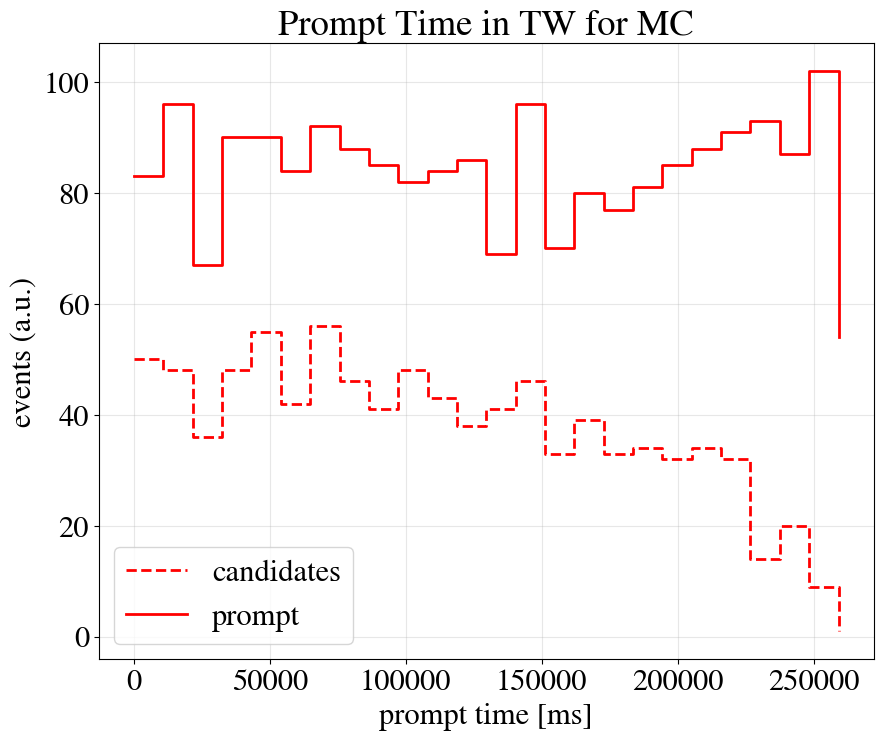

In [1071]:
# Build candidate table (unique prompt per TW/event)
df2 = df.copy()
df2["prompt_time"] = pd.to_numeric(df2["prompt_time"], errors="coerce")
df2 = df2.dropna(subset=["event_number", "prompt_time"])

times = (df2[["event_number", "prompt_time"]]
         .drop_duplicates()
         .sort_values(["event_number", "prompt_time"]))

# number of prompts per event (TW)
n_prompts = times.groupby("event_number")["prompt_time"].size()

# 1) ALL prompt-candidate times (one entry per candidate)
prompt_nhits_bkg = times["prompt_time"].to_numpy()          # or .tolist()

# 2) candidate times for events that have ONLY 1 prompt
one_prompt_events = n_prompts[n_prompts == 1].index
prompt_nhits_bkg2 = times.loc[times["event_number"].isin(one_prompt_events),
                              "prompt_time"].to_numpy()     # or .tolist()

# Signal times (as you already do)
prompt_nhits = df_gamma["prompt_ti"].to_numpy()

# --- plotting (your code) ---
hist, bins_edges = np.histogram(prompt_nhits_bkg, bins=25, range=(0, 270000))
hist_sig, _ = np.histogram(prompt_nhits, bins=bins_edges)
hist2, _ = np.histogram(prompt_nhits_bkg2, bins=bins_edges)

plt.figure()
plt.step(bins_edges[:-1], hist, where='post', label='candidates', color='red', lw=2, linestyle='--')
#plt.step(bins_edges[:-1], hist2, where='post', label='candidates, prompt = 1', color='red', lw=2, linestyle='--')
plt.step(bins_edges[:-1], hist_sig, where='post', label='prompt', color='red', lw=2)

plt.xlabel('prompt time [ms]')
plt.ylabel('events (a.u.)')
plt.title(f'Prompt Time in TW for MC')
plt.legend()
plt.grid(alpha=0.3)

print(len(prompt_nhits_bkg2))

In [1072]:
nBG = 5
deltat_vp = 50000

df['dt'] = 270000 - df['prompt_time']
mask = df['dt'] < (deltat_vp * nBG) 
vp_times_by_event = {}
for event, group in df.loc[mask].groupby('event_number'):
    t0 = group['prompt_time'].iloc[0]   # or use .min() if preferred
    vp_times_by_event[event] = [t0 + j * deltat_vp for j in range(nBG)]

total_vp_times = sum(len(v) for v in vp_times_by_event.values())
print("total vp times:", total_vp_times)

total vp times: 4110


In [1073]:
N_events_sig = np.max(df["event_number"])
#N_events_acc = np.max(df_acc["event_number"])*nBG

N_events_sel_sig = df["event_number"].nunique()
#N_events_sel_acc = df_acc["event_number"].nunique() 

print("Signal Time Windows", N_events_sig)
#print("Acc Time Windows", N_events_acc)

print("Events Signal", N_events_sel_sig)
#print("Events Acc", N_events_sel_acc)

print("Signal Events/Second", N_events_sel_sig/(N_events_sig*270*1e-6))
#print("Acc Events/Second", N_events_sel_acc/(N_events_acc*270*1e-6))

print("Candidate events/Second", N_events_sel_sig/(N_events_sig*270*1e-6))


# Count entries per event_number
event_counts = df['event_number'].value_counts()

# Number of events with more than one entry
num_events_multiple_entries = (event_counts > 1).sum()
print(f"Number of events with more than one entry: {num_events_multiple_entries}")

Signal Time Windows 99975
Events Signal 917
Signal Events/Second 33.971455826919694
Candidate events/Second 33.971455826919694
Number of events with more than one entry: 5


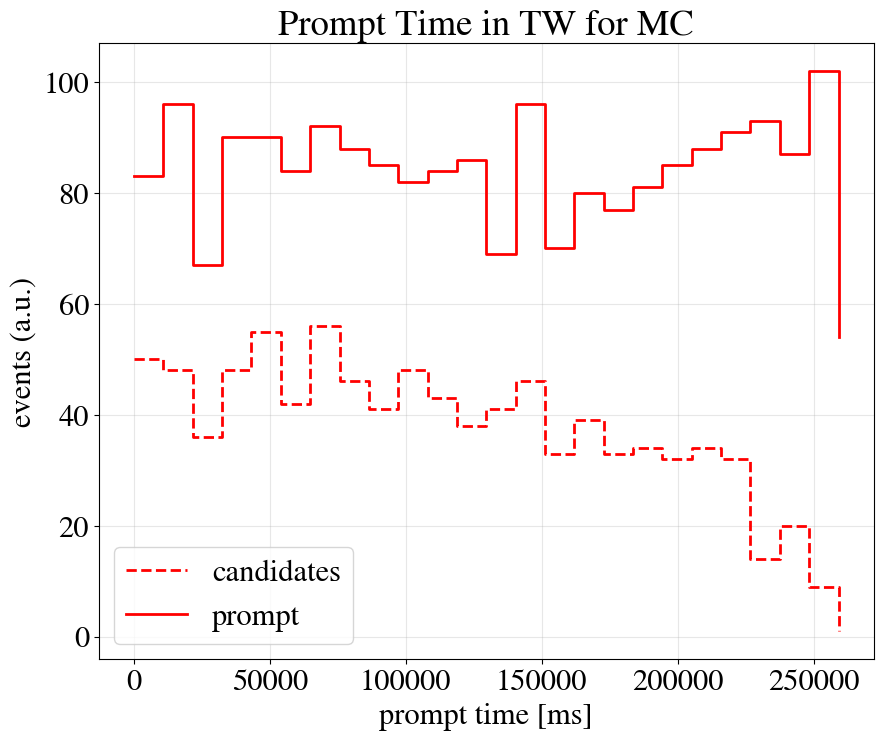

In [1074]:
prompt_nhits = df_gamma.prompt_ti.values
prompt_nhits_bkg = df.prompt_time.unique()

hist, bins_edges = np.histogram(prompt_nhits_bkg, bins=25, range=(0, 270000))
hist_sig, _ = np.histogram(prompt_nhits, bins = bins_edges)

plt.figure()
plt.step(bins_edges[:-1], hist, where='post', label=f'candidates', color='red', lw=2, linestyle = '--')
plt.step(bins_edges[:-1], hist_sig , where='post', label=f'prompt', color='red', lw=2)
plt.xlabel('prompt time [ms]')
plt.ylabel('events (a.u.)')
plt.title(f'Prompt Time in TW for MC')
#plt.yscale('log') 
plt.legend()
plt.grid(alpha=0.3)
#print(hist_sig)

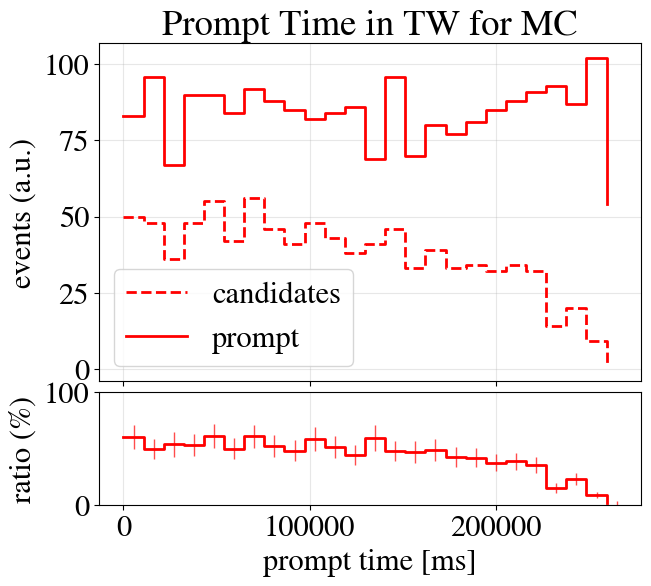

In [1075]:
prompt_nhits = df_gamma.prompt_ti.values
prompt_nhits_bkg = df.prompt_time.unique()

# --- histograms (same binning) ---
hist, bins_edges = np.histogram(prompt_nhits_bkg, bins=25, range=(0, 270000))
hist_sig, _      = np.histogram(prompt_nhits,     bins=bins_edges)  # prompt

# --- ratio (cand / prompt), in percent ---
ratio = np.divide(
    hist.astype(float),
    hist_sig.astype(float),
    out=np.full_like(hist, np.nan, dtype=float),
    where=(hist_sig != 0)
) * 100.0

# Simple propagated error assuming Poisson counts in both:
# r = (A/B)*100 ;  σ_r/r = sqrt( (σA/A)^2 + (σB/B)^2 ) with σA=sqrt(A), σB=sqrt(B)
A = hist.astype(float)      # candidates
B = hist_sig.astype(float)  # prompt
ratio_err = np.full_like(ratio, np.nan, dtype=float)
mask = (A > 0) & (B > 0)
ratio_err[mask] = ratio[mask] * np.sqrt(1.0 / A[mask] + 1.0 / B[mask])

# x coordinates for "post" steps
x = bins_edges[:-1]

# --- figure with ratio panel ---
fig, (ax, rax) = plt.subplots(
    2, 1, sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    figsize=(7, 6)
)

# top
ax.step(x, hist, where="post", label="candidates", color="red", lw=2, linestyle="--")
ax.step(x, hist_sig, where="post", label="prompt", color="red", lw=2)
ax.set_ylabel("events (a.u.)")
ax.set_title(f"Prompt Time in TW for MC")
ax.legend()
ax.grid(alpha=0.3)

# bottom ratio
#rax.axhline(60.0,  color="red",   lw=2, alpha=0.9, ls="--")     # 60% reference line
rax.step(x, ratio, where="post", color="red", lw=2)

# optional: ratio error bars at bin centers
centers = 0.5 * (bins_edges[:-1] + bins_edges[1:])
rax.errorbar(centers, ratio, yerr=ratio_err, fmt="none", ecolor="red", elinewidth=1, alpha=0.7)

rax.set_xlabel("prompt time [ms]")
rax.set_ylabel("ratio (%)")
rax.set_ylim(0, 100)# np.nanmax(ratio) * 1.2 if np.isfinite(np.nanmax(ratio)) else 200)
rax.grid(alpha=0.3)

plt.show()

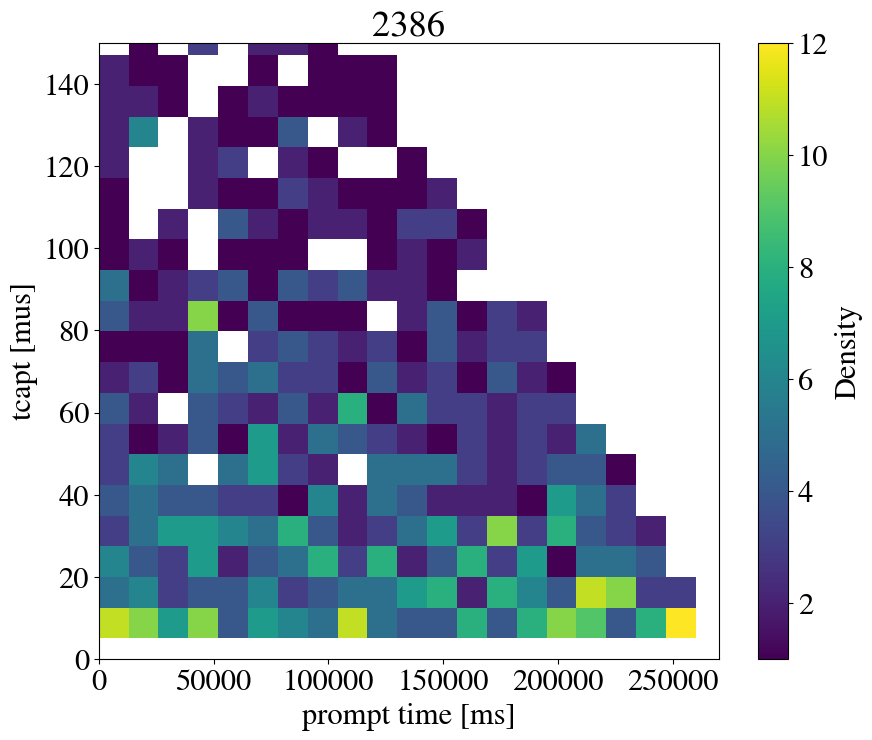

In [1076]:
plt.hist2d(df.prompt_time.values, df.DeltaT.values, bins=20, cmin=0.0001)
plt.colorbar(label='Density')
plt.xlim(0, 270000)  # Set x-axis limits
plt.ylim(0, 150)
plt.ylabel('tcapt [mus]')
plt.xlabel('prompt time [ms]')
plt.title(f'{sig_run}')
plt.show()

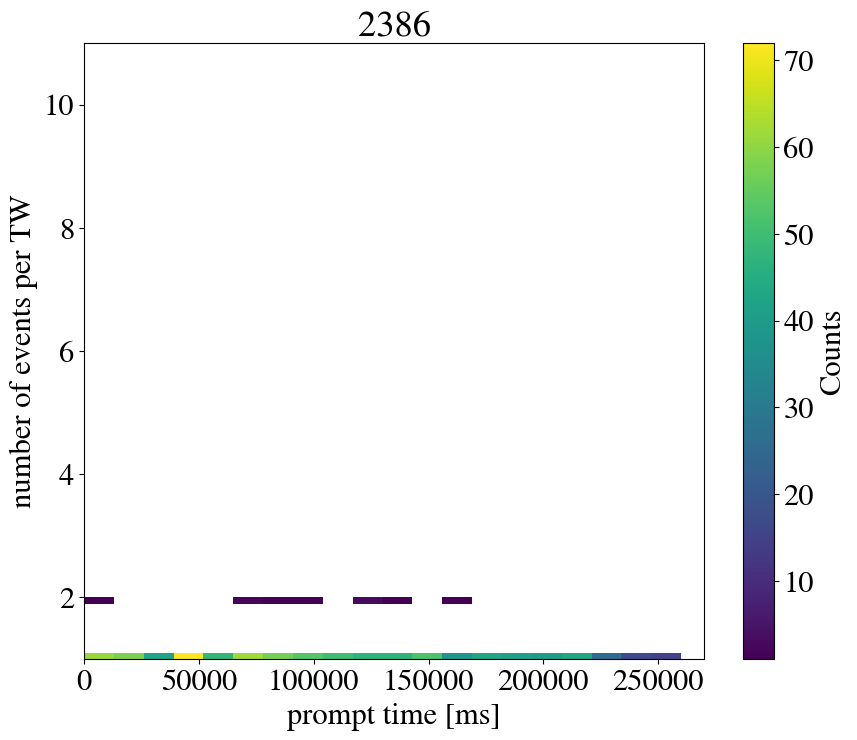

In [1077]:
n_events_per_tw = df.groupby("event_number")["event_number"].transform("size")

plt.hist2d(
    df["prompt_time"].to_numpy(),
    n_events_per_tw.to_numpy(),
    bins=[20, 10],
    cmin=0.0001
)
plt.colorbar(label="Counts")  # hist2d returns counts per bin (not a probability density unless density=True)
plt.xlim(0, 270000)
plt.ylim(1, 11)
plt.ylabel("number of events per TW")
plt.xlabel("prompt time [ms]")
plt.title(f"{sig_run}")
plt.show()

In [1078]:
n_events_per_tw = df.groupby("event_number")["event_number"].transform("size")
n_prompts_per_tw = df_gamma.groupby("event_number")["prompt_ti"].transform("size")

len(n_prompts_per_tw), len(n_events_per_tw)

(2104, 922)

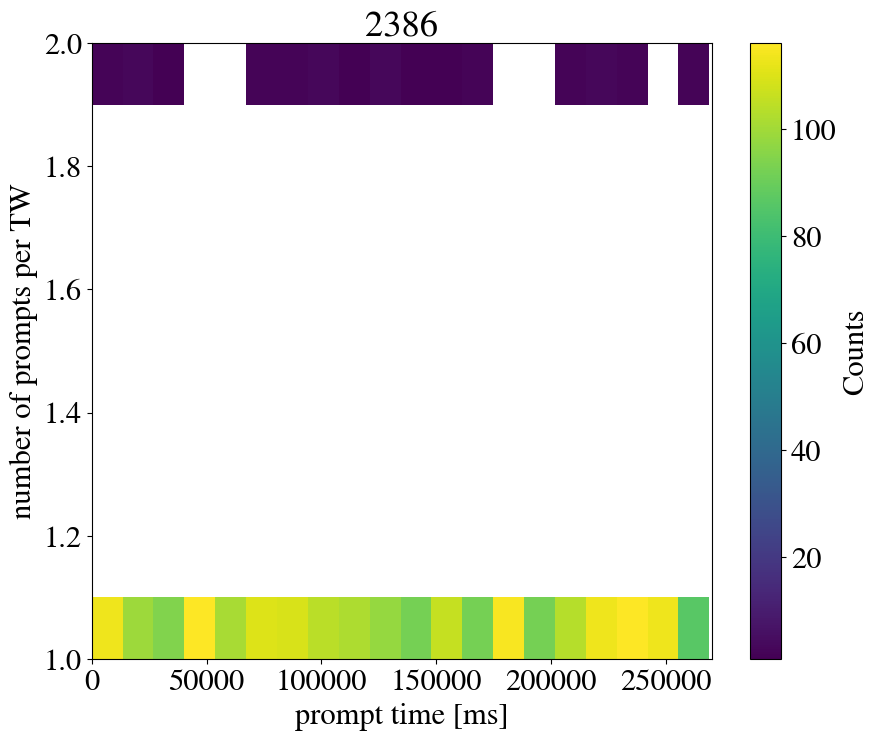

In [1079]:
n_prompts_per_tw = df_gamma.groupby("event_number")["prompt_ti"].transform("size")

plt.hist2d(
    df_gamma["prompt_ti"].to_numpy(),
    n_prompts_per_tw.to_numpy(),
    bins=[20, 10],
    cmin=0.0001
)
plt.colorbar(label="Counts")  # hist2d returns counts per bin (not a probability density unless density=True)
plt.xlim(0, 270000)
#plt.ylim(1, 11)
plt.ylabel("number of prompts per TW")
plt.xlabel("prompt time [ms]")
plt.title(f"{sig_run}")
plt.show()

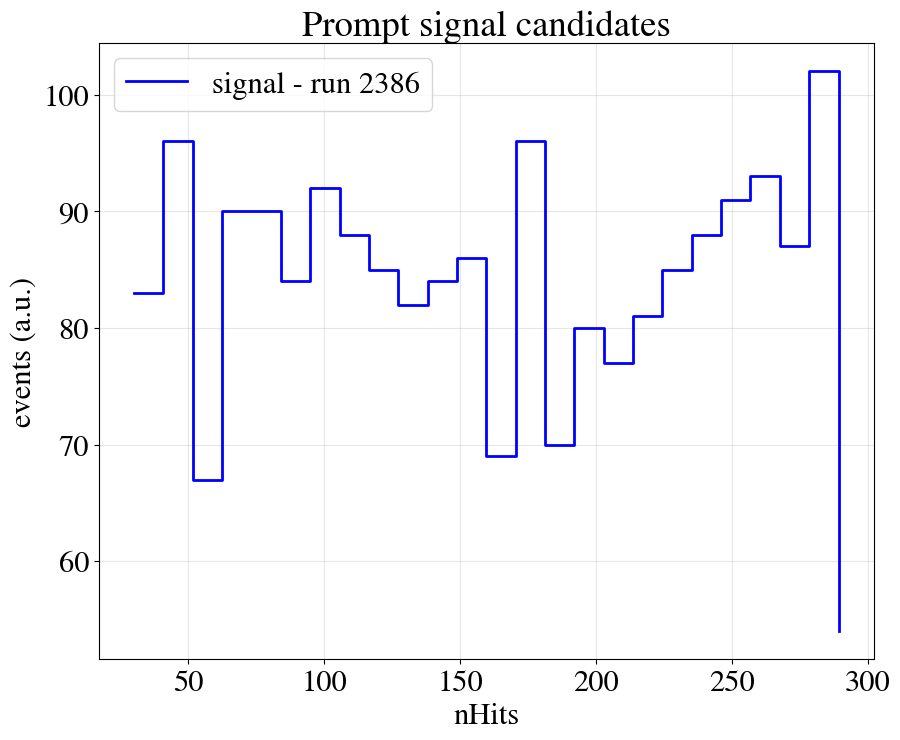

In [1080]:
prompt_nhits = df.prompt_nhits.values

hist, bins_edges = np.histogram(prompt_nhits, bins=25, range=(prompt_nhits_min, prompt_nhits_max))

plt.figure()
plt.step(bins_edges[:-1], hist_sig , where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
#plt.step(bins_edges[:-1], hist_sig*N_events_bkg/N_events_sig - hist, where='post', linewidth=2, color='green', label=f'signal - bkg')
plt.xlabel('nHits')
plt.ylabel('events (a.u.)')
plt.title('Prompt signal candidates')
#plt.yscale('log') 
plt.legend()
plt.grid(alpha=0.3)

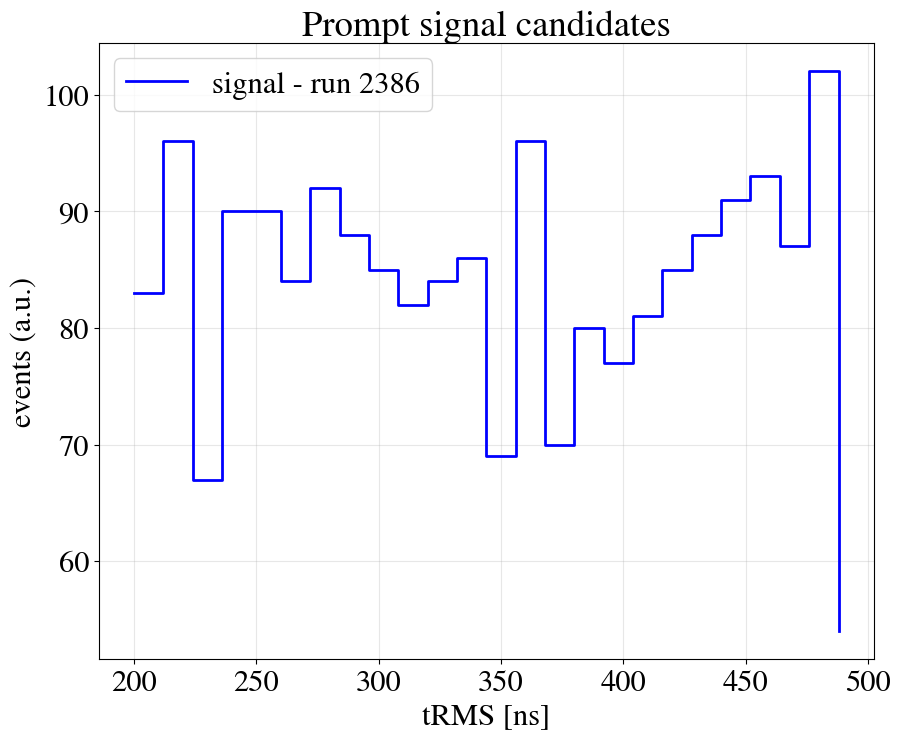

In [1081]:
prompt_nhits = df_gamma.prompt_trms.values

hist, bins_edges = np.histogram(prompt_nhits, bins=25, range=(prompt_t_rms_min, prompt_t_rms_max))

plt.figure()
plt.step(bins_edges[:-1], hist_sig , where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('tRMS [ns]')
plt.ylabel('events (a.u.)')
plt.title('Prompt signal candidates')
plt.legend()
plt.grid(alpha=0.3)

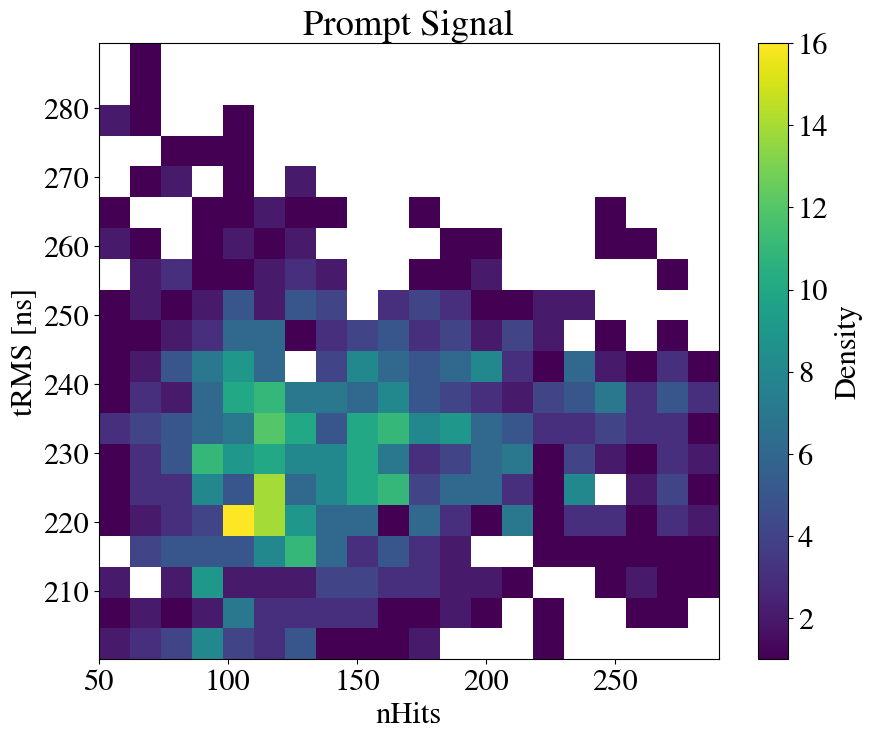

In [1082]:
plt.hist2d(df.prompt_nhits.values, df.prompt_trms.values, bins=20, cmin=0.0001)
plt.colorbar(label='Density')
#plt.xlim(0, 270000)  # Set x-axis limits
#plt.ylim(0, 150)
plt.ylabel('tRMS [ns]')
plt.xlabel('nHits')
plt.title(f'Prompt Signal')
plt.show()

In [1083]:
#df = df[(df.delayed_x < 200) & (df.delayed_x > -200) & (df.delayed_y < 200) & (df.delayed_y > -200) & (df.delayed_z < 200) & (df.delayed_z > -200)]
#df_bkg = df_bkg[(df_bkg.delayed_x < 200) & (df_bkg.delayed_x > -200) & (df_bkg.delayed_y < 200) & (df_bkg.delayed_y > -200) & (df_bkg.delayed_z < 200) & (df_bkg.delayed_z > -200)]

#df_acc = df_acc[(df_acc.vp_delayed_x < 200) & (df_acc.vp_delayed_x > -200) & (df_acc.vp_delayed_y < 200) & (df_acc.vp_delayed_y > -200) & (df_acc.vp_delayed_z < 200) & (df_acc.vp_delayed_z > -200)]

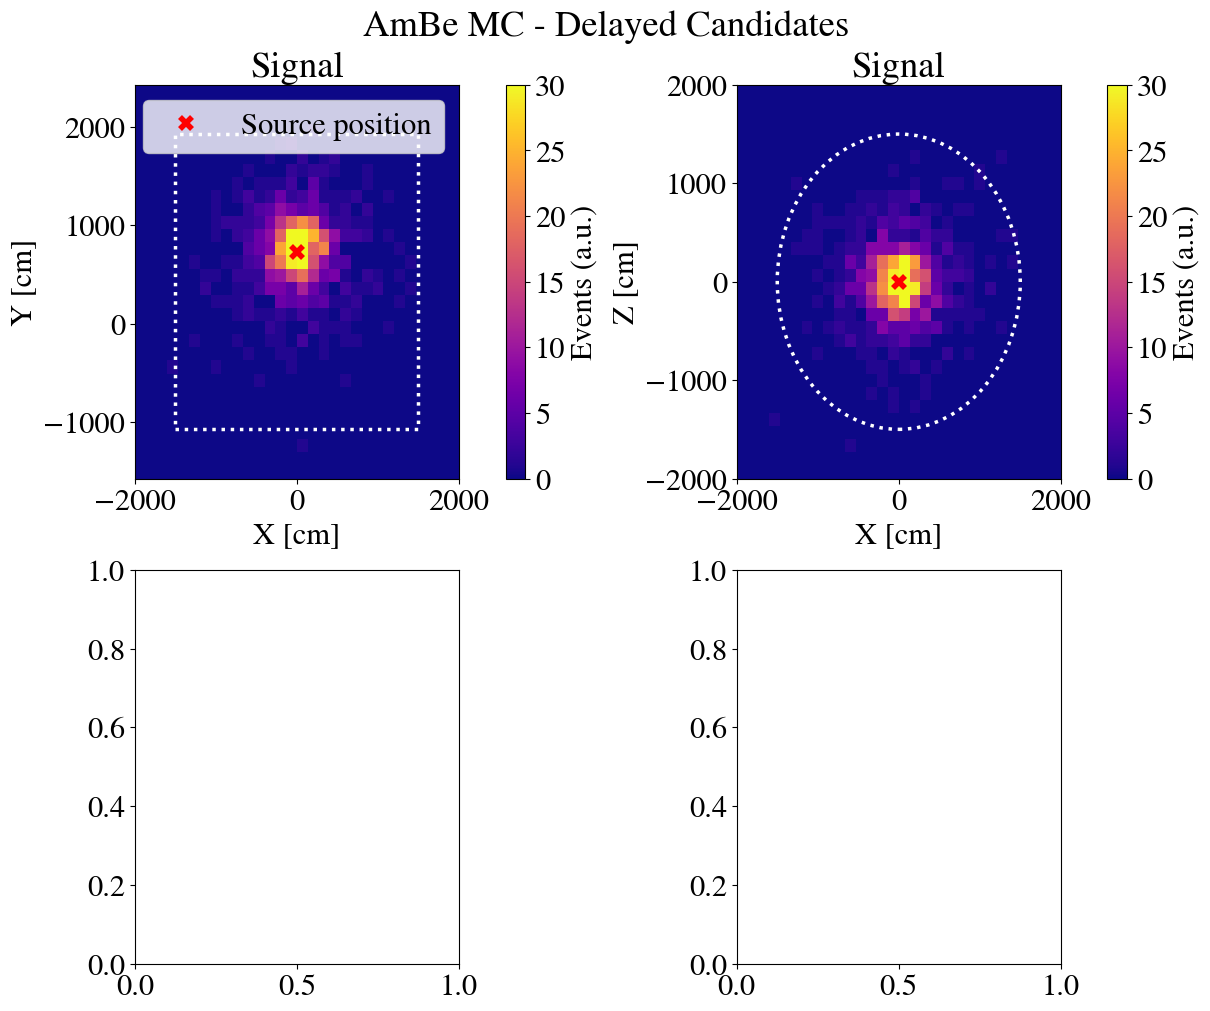

In [1084]:
cols = ["delayed_x", "delayed_y", "delayed_z"]
labels = ["X [cm]", "Y [cm]", "Z [cm]"]
source_pos = {"prompt_x": pos[0], "prompt_y": pos[1], "prompt_z": pos[2]}

alpha = 1  # scale signal to background exposure

# Clean arrays
def clean(arr):
    arr = np.asarray(arr)
    return arr[np.isfinite(arr)]

sx, sy, sz = [clean(df[c].to_numpy()) for c in cols]

n_bins = 30

global_min = 0 
global_max = 30

# Shared bin ranges for consistency
xmin, xmax = -2000, 2000
ymin, ymax = -2000+424.725, 2000+424.725
zmin, zmax = -2000, 2000
xbins = np.linspace(xmin, xmax, n_bins+1)
ybins = np.linspace(ymin, ymax, n_bins+1)
zbins = np.linspace(zmin, zmax, n_bins+1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)


# --------------------------
# Shape parameters
# --------------------------
# Rectangle for XY
rect_xmin, rect_xmax = -1500, 1500
rect_ymin, rect_ymax = -1500+424.725, 1500+424.725

# Circle for XZ
circle_center = (0, 0)   # (x, z)
circle_radius = 1500

shape_style = dict(
    fill=False,
    edgecolor="white",
    linestyle=":",
    linewidth=2.5
)

# SIGNAL: X vs Y
h_sig_xy, xedges, yedges, img_sig_xy = axes[0,0].hist2d(
    sx, sy, bins=[xbins, ybins], weights=np.full(sx.shape, alpha),
    cmap='plasma', vmin=global_min, vmax=global_max
)
axes[0,0].plot(source_pos["prompt_x"], source_pos["prompt_y"], 'rx', ms=8, mew=4, label='Source position')
axes[0,0].set_xlabel(labels[0]); axes[0,0].set_ylabel(labels[1])
axes[0,0].set_title("Signal")
axes[0,0].legend()
fig.colorbar(img_sig_xy, ax=axes[0,0], label="Events (a.u.)")

# Add rectangle on XY
rect_xy = patches.Rectangle(
    (rect_xmin, rect_ymin),
    rect_xmax - rect_xmin,
    rect_ymax - rect_ymin,
    **shape_style
)
axes[0,0].add_patch(rect_xy)

# SIGNAL: X vs Z
h_sig_xz, xedges, zedges, img_sig_xz = axes[0,1].hist2d(
    sx, sz, bins=[xbins, zbins], weights=np.full(sx.shape, alpha),
    cmap='plasma', vmin=global_min, vmax=global_max
)
axes[0,1].plot(source_pos["prompt_x"], source_pos["prompt_z"], 'rx', ms=8, mew=4, label='Source position')
axes[0,1].set_xlabel(labels[0]); axes[0,1].set_ylabel(labels[2])
axes[0,1].set_title("Signal")
#axes[0,1].legend()
fig.colorbar(img_sig_xz, ax=axes[0,1], label="Events (a.u.)")

# Add circle on XZ
circle_xz = patches.Circle(
    circle_center, circle_radius, **shape_style
)
axes[0,1].add_patch(circle_xz)

fig.suptitle(f"AmBe MC - Delayed Candidates")
plt.show()

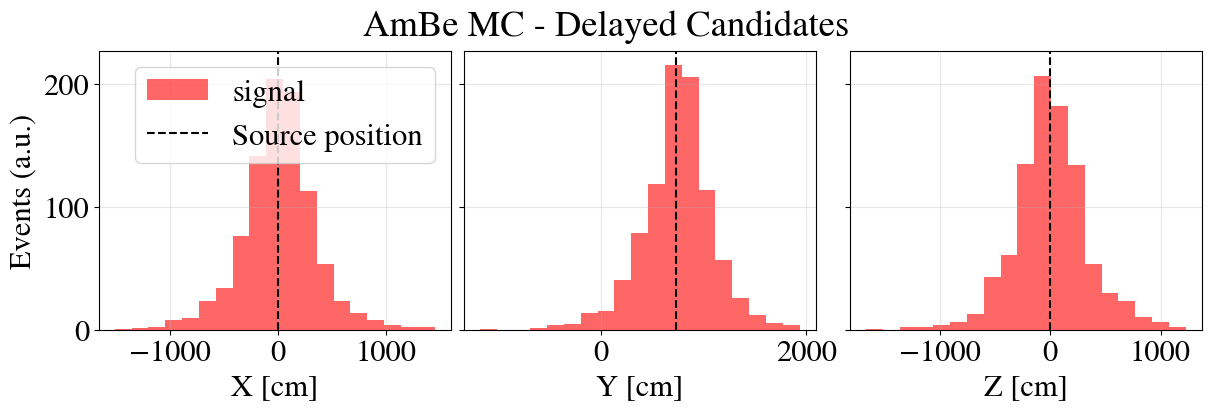

In [1085]:
cols = ["delayed_x", "delayed_y", "delayed_z"]
labels = ["X [cm]", "Y [cm]", "Z [cm]"]

source_pos = {"delayed_x": pos[0], "delayed_y": pos[1], "delayed_z": pos[2]}

alpha = 1  # scale signal to background exposure

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, constrained_layout=True)

for ax, col, label in zip(axes, cols, labels):
    # Drop non-finite
    s = df[col].to_numpy()
    s = s[np.isfinite(s)]

    # Common bins from combined range
    xmin = s.min()
    xmax = s.max()
    bins = np.linspace(xmin, xmax, 20)  # 50 bins

    # Histograms: scale signal counts by alpha via weights
    ax.hist(s, bins=bins, weights=np.full(s.shape, alpha), color="red", alpha=0.6, label=f'signal')

    # Source marker line
    vline = source_pos[col]
    ax.axvline(vline, color="k", linestyle="--", linewidth=1.5, label="Source position")

    ax.set_xlabel(label)
    ax.grid(alpha=0.3)
    if(col =='delayed_x'):
        ax.legend()

axes[0].set_ylabel("Events (a.u.)")
fig.suptitle(f"AmBe MC - Delayed Candidates")
plt.show()

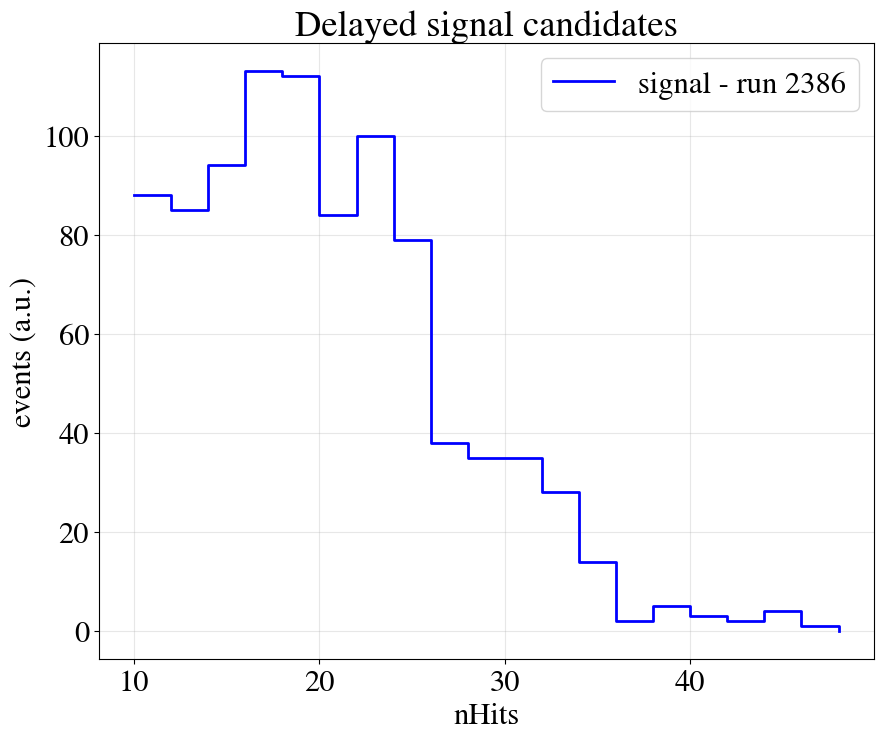

In [1086]:
prompt_nhits = df.delayed_nhits.values

hist, bins_edges = np.histogram(prompt_nhits, bins=20, range=(delayed_nhits_min, delayed_nhits_max))

plt.figure()
plt.step(bins_edges[:-1], hist, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel('nHits')
plt.ylabel('events (a.u.)')
plt.title('Delayed signal candidates')
plt.legend()
plt.grid(alpha=0.3)

In [1087]:
df

,event_number,prompt_nhits,prompt_time,prompt_trms,prompt_tmean,delayed_time_tof,delayed_nhits,delayed_trms_tof,delayed_x,delayed_y,delayed_z,vertex_chi2,delayed_r,prompt_r,DeltaR,DeltaT,numb_prompts,dt
0,108,210,68279.819523,222.036195,264.764045,74300.148008,19,1.342016,-678.488185,1059.778205,-145.195785,20.678316,1266.711442,729.725,536.986442,6.020328,1,201720.180477
1,188,107,232978.713388,237.644532,273.812151,248862.707076,41,1.395626,-199.984915,825.340513,236.596706,8.273008,881.566180,729.725,151.841180,15.883994,1,37021.286612
2,250,99,215103.476128,256.326322,292.615777,266517.696139,20,1.713678,897.952136,1175.862488,114.083284,13.552012,1483.908901,729.725,754.183901,51.414220,1,54896.523872
3,292,171,39241.446611,265.926100,305.095740,188977.985498,31,1.393510,-265.331605,876.047117,115.917908,18.605713,922.657235,729.725,192.932235,149.736539,1,230758.553389
4,533,102,71984.862564,217.807840,255.392319,124130.831257,10,0.765874,-242.513182,1336.295274,-26.856169,11.228511,1358.388367,729.725,628.663367,52.145969,1,198015.137436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1001,99218,187,148686.480995,252.193737,266.105793,168478.659049,23,2.494409,-473.683322,1101.556181,78.308626,12.963933,1201.638111,729.725,471.913111,19.792178,1,121313.519005
1002,99252,191,203499.958079,243.969264,258.593482,231244.033093,14,1.086071,-53.600773,875.459578,-277.686299,11.976316,920.006629,729.725,190.281629,27.744075,1,66500.041921
1004,99771,114,95975.476707,203.337420,239.698705,147514.848877,35,2.221089,-96.521061,1603.989744,202.002839,9.153887,1619.538378,729.725,889.813378,51.539372,1,174024.523293
1005,99824,234,25956.139222,219.506976,253.774769,44640.859706,34,0.807379,-57.600996,764.072001,-200.270618,6.786826,791.979935,729.725,62.254935,18.684720,1,244043.860778


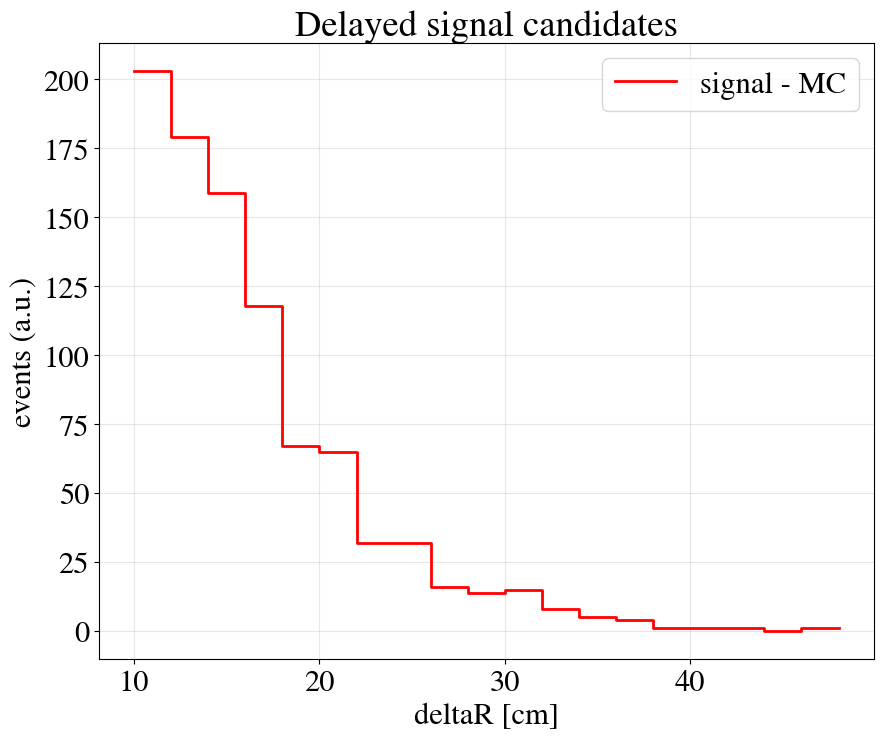

In [1088]:
x = df["DeltaR"].dropna().to_numpy()
hist, bin_edges = np.histogram(x, bins=20)

plt.figure()
plt.step(bins_edges[:-1], hist, where='post', label=f'signal - MC', color='red', lw=2)
plt.xlabel('deltaR [cm]')
plt.ylabel('events (a.u.)')
plt.title('Delayed signal candidates')
plt.legend()
plt.grid(alpha=0.3)

In [1089]:
print(title)

2386_prompt50threshold_prompt1000window_tmeanlimits_neutronsel_mult_wtfilter_w10ns_mtrms10_wTOF


47.627363480436784
Seed used: A0=97, tau0=47.63
Ajuste: A = 106.72 ± 3.43, tau = 44.98 ± 4.09, B = 3.23 ± 2.52


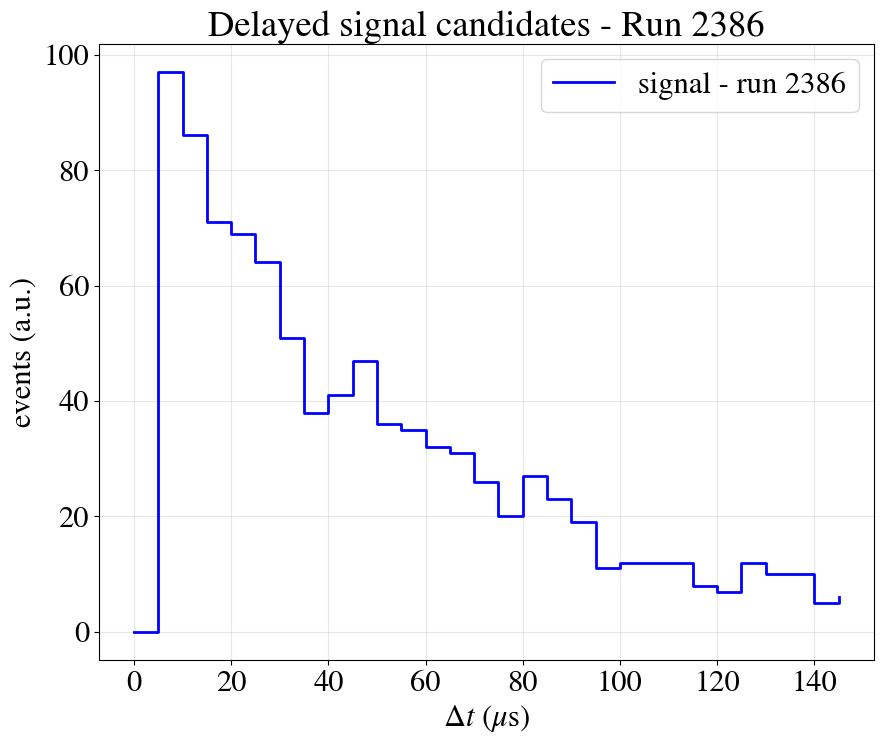

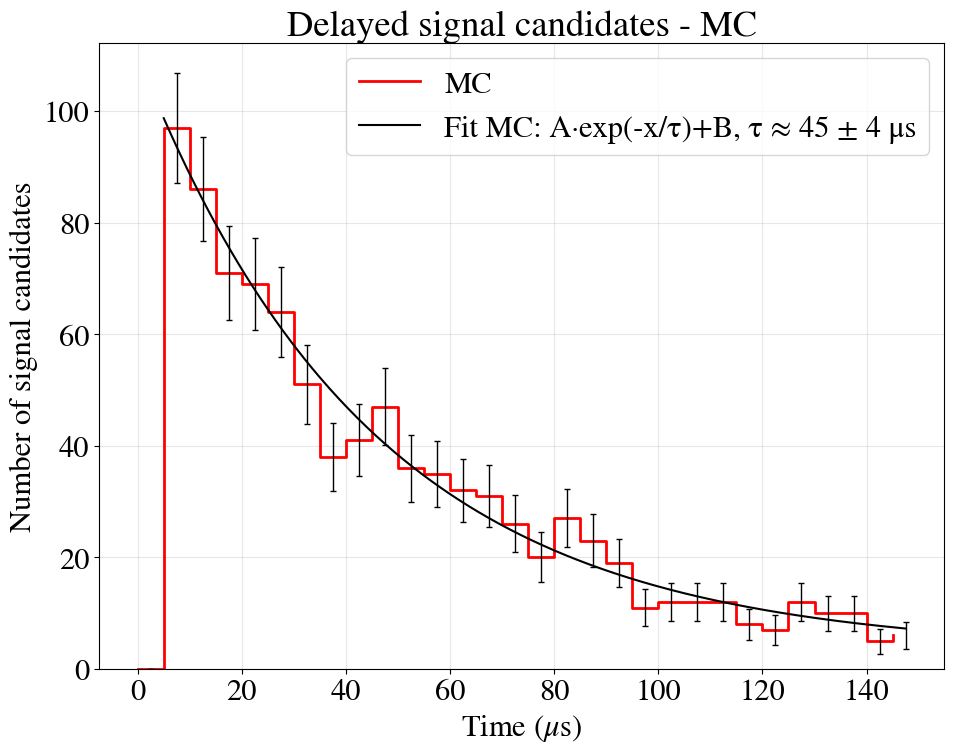

In [1090]:
prompt_nhits = df.DeltaT.values
print(f'{np.mean(df.DeltaT.values)}')

hist, bins_edges = np.histogram(prompt_nhits, bins=30, range=(0, 150))

plt.figure()
plt.step(bins_edges[:-1], hist, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel(r'$\Delta t$ ($\mu$s)')
plt.ylabel('events (a.u.)')
plt.title(f'Delayed signal candidates - Run {sig_run}')
plt.legend()
plt.grid(alpha=0.3)

bin_centers = 0.5 * (bins_edges[:-1] + bins_edges[1:])
values = hist

# histogram pieces you already have
hist_deltar, bins_edges = np.histogram(df.DeltaR.values, bins=100, range=(0, 1500))
bin_centers_deltar = 0.5 * (bins_edges[:-1] + bins_edges[1:])

hist_prompt_nhits, bins_edges = np.histogram(df.prompt_nhits.values, bins=30, range=(30, 300))
bin_centers_prompt_nhits = 0.5 * (bins_edges[:-1] + bins_edges[1:])

hist_delayed_nhits, bins_edges = np.histogram(df.delayed_nhits.values, bins=20, range=(10, 50))
bin_centers_delayed_nhits = 0.5 * (bins_edges[:-1] + bins_edges[1:])

hist_prompt_trms, bins_edges = np.histogram(df.prompt_trms.values, bins=30, range=(200, 500))
bin_centers_prompt_trms = 0.5 * (bins_edges[:-1] + bins_edges[1:])

hist_delayed_trms, bins_edges = np.histogram(df.delayed_trms_tof.values, bins=30, range=(0, 10))
bin_centers_delayed_trms = 0.5 * (bins_edges[:-1] + bins_edges[1:])

hist_deltat, bins_edges = np.histogram(df.DeltaT.values, bins=30, range=(0, 150))
bin_centers_deltat = 0.5 * (bins_edges[:-1] + bins_edges[1:])


np.savez(
    f'/data/halmazan/WCTE/data/AmBeCandidates/histograms_MC_{title}.npz',
    deltat=hist_deltat,
    bins_deltat=bin_centers,
    deltaR=hist_deltar,
    bins_deltaR=bin_centers_deltar,
    prompt_nhits=hist_prompt_nhits,
    bins_prompt_nhits=bin_centers_prompt_nhits,
    delayed_nhits=hist_delayed_nhits,
    bins_delayed_nhits=bin_centers_delayed_nhits,
    prompt_trms=hist_prompt_trms,
    bins_prompt_trms=bin_centers_prompt_trms,
    delayed_trms=hist_delayed_trms,
    bins_delayed_trms=bin_centers_delayed_trms,
)

scale = 1
sig_scaled = hist * scale
data = hist

# Proper approx errors for (scale*sig - bkg)
errors = np.sqrt(hist)

xmin = 5.0  # microseconds

mask = (
    np.isfinite(errors) &
    (errors > 0) &
    (bin_centers > xmin)
    # optional:
    # & (data > 0)
)

# Fit only bins with finite errors and positive content (optional but helps)
#mask = np.isfinite(errors) & (errors > 0) & (data > 0)

x = bin_centers[mask]
y = data[mask]
s = errors[mask]

def exp_func(x, A, tau, B):
    return A*np.exp(-x/tau)+B

tau0 = np.mean(df.DeltaT.values)   # seed you want
A0   = np.max(data)                   # typical seed for amplitude
B0   = np.min(data)   

p0 = (A0, tau0, B0)

popt, pcov = curve_fit(exp_func, x, y, p0=p0)
A_fit, tau_fit, B_fit = popt
A_err, tau_err, B_err = np.sqrt(np.diag(pcov))

print(f"Seed used: A0={A0:.4g}, tau0={tau0:.4g}")
print(f"Ajuste: A = {A_fit:.2f} ± {A_err:.2f}, tau = {tau_fit:.2f} ± {tau_err:.2f}, B = {B_fit:.2f} ± {B_err:.2f}")

plt.figure()
plt.step(bins_edges[:-1], data, where='post', linewidth=2, label='MC', color='red')
plt.errorbar(bin_centers, data, yerr=errors, fmt='none', ecolor='black', elinewidth=1, capsize=2)
x_fit = np.linspace(xmin, bin_centers[mask].max(), 400)
plt.plot(x_fit, exp_func(x_fit, *popt), '-', color="black", label=f'Fit MC: A·exp(-x/τ)+B, τ ≈ {tau_fit:.0f} ± {tau_err:.0f} μs')
#x_fit = np.arange(int(bin_centers[1]), int(bin_centers[-6]), 1)
#plt.plot(x_fit, exp_func(x_fit, *popt), 'r-', label=f'Fit data: A·exp(-x/τ), τ ≈ {tau_fit:.0f} ± {tau_err:.0f} μs', color="black")
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel('Number of signal candidates')
plt.grid(alpha=0.3)
plt.title(f'Delayed signal candidates - MC')
plt.legend()
plt.tight_layout()
plt.ylim(bottom = 0)
plt.show()


In [1091]:
df = df[(df.delayed_x < (pos[0]+60)) & (df.delayed_x > (pos[0]-60)) & (df.delayed_y < (pos[1]+60)) & (df.delayed_y > (pos[1]-60)) & (df.delayed_z < (pos[2]+60)) & (df.delayed_z > (pos[2]-60))]
df_bkg = df_bkg[(df_bkg.delayed_x < (pos[0]+60)) & (df_bkg.delayed_x > (pos[0]-60)) & (df_bkg.delayed_y < (pos[1]+60)) & (df_bkg.delayed_y > (pos[1]-60)) & (df_bkg.delayed_z < (pos[2]+60)) & (df_bkg.delayed_z > (pos[2]-60))]


NameError: name 'df_bkg' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cols = ["delayed_x", "delayed_y", "delayed_z"]
labels = ["X [cm]", "Y [cm]", "Z [cm]"]

source_pos = {"delayed_x": pos[0], "delayed_y": pos[1], "delayed_z": pos[2]}
alpha = N_events_bkg / N_events_sig  # scale signal to background exposure

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, constrained_layout=True)

for ax, col, label in zip(axes, cols, labels):
    s = df[col].to_numpy()
    b = df_bkg[col].to_numpy()
    s = s[np.isfinite(s)]
    b = b[np.isfinite(b)]

    # Common bins from combined range
    xmin = np.min([s.min(), b.min()]) if len(s) and len(b) else (s.min() if len(s) else b.min())
    xmax = np.max([s.max(), b.max()]) if len(s) and len(b) else (s.max() if len(s) else b.max())
    bins = np.linspace(xmin, xmax, 20)

    # Bin counts and subtraction: (scaled signal) - background
    s_counts, _ = np.histogram(s, bins=bins)
    b_counts, _ = np.histogram(b, bins=bins)
    diff = alpha * s_counts - b_counts

    # (optional) Poisson uncertainty band: Var = alpha^2*S + B
    diff_sigma = np.sqrt((alpha**2) * s_counts + b_counts)

    # Plot only the subtraction
    ax.step(bins[:-1], diff, where="post", color="k", linewidth=2, label="candidates")
    ax.fill_between(
        bins[:-1], diff - diff_sigma, diff + diff_sigma,
        step="post", color="k", alpha=0.15, linewidth=0
    )
    ax.axhline(0, color="k", linewidth=1, alpha=0.4)

    # Source marker line
    ax.axvline(source_pos[col], color="k", linestyle="--", linewidth=1.5, label="Source position")

    ax.set_xlabel(label)
    ax.grid(alpha=0.3)
    if col == "delayed_x":
        ax.legend()

axes[0].set_ylabel("Events (scaled subtraction)")
fig.suptitle(f"AmBe Run {sig_run} - Delayed Candidates (Subtracted)")
plt.show()

NameError: name 'N_events_bkg' is not defined

In [ ]:
prompt_nhits = df.DeltaT.values
prompt_nhits_bkg = df_bkg.DeltaT.values

hist, bins_edges = np.histogram(prompt_nhits_bkg, bins=25, range=(0, 150))
hist_sig, _ = np.histogram(prompt_nhits, bins = bins_edges)

plt.figure()
plt.step(bins_edges[:-1], hist, where='post', label=f'background - run {bkg_run}', color='red', lw=2)
plt.step(bins_edges[:-1], hist_sig * N_events_bkg / N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel(r'$\Delta t$ ($\mu$s)')
plt.ylabel('events (a.u.)')
plt.title(f'Delayed signal candidates - Run {sig_run}')
plt.legend()
plt.grid(alpha=0.3)

plt.figure()
plt.step(bins_edges[:-1], hist_sig*N_events_bkg/N_events_sig - hist, where='post', linewidth=2, color='green', label=f'signal - bkg')
plt.xlabel(r'$\Delta t$ ($\mu$s)')
plt.ylabel('Number of signal candidates')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

bin_centers = 0.5 * (bins_edges[:-1] + bins_edges[1:])
values = hist_sig * N_events_bkg / N_events_sig - hist

np.savez(f'/data/halmazan/WCTE/data/AmBeCandidates/histograms_run{sig_run}_40ns.npz', deltat=values, bins_deltat=bin_centers)


scale = N_events_bkg / N_events_sig
sig_scaled = hist_sig * scale
data = sig_scaled - hist

# Proper approx errors for (scale*sig - bkg)
errors = np.sqrt((scale**2) * hist_sig + hist)

xmin = 20.0  # microseconds

mask = (
    np.isfinite(errors) &
    (errors > 0) &
    (bin_centers > xmin)
    # optional:
    # & (data > 0)
)

# Fit only bins with finite errors and positive content (optional but helps)
#mask = np.isfinite(errors) & (errors > 0) & (data > 0)

x = bin_centers[mask]
y = data[mask]
s = errors[mask]

def exp_func(x, A, tau):
    return A*np.exp(-x/tau)

p0 = (y.max(), 30.0, 0.0)
bounds = ([0, 1e-3, -np.inf], [np.inf, np.inf, np.inf])

popt, pcov = curve_fit(exp_func, x, y, p0=(x.max(), 30.0))
A_fit, tau_fit = popt
A_err, tau_err = np.sqrt(np.diag(pcov))  # Error en A y tau

print(f"Ajuste: A = {A_fit:.2f}, tau = {tau_fit:.2f}")

plt.figure()
plt.step(bins_edges[:-1], data, where='post', linewidth=2, label='Data', color='green')
plt.errorbar(bin_centers, data, yerr=errors, fmt='none', ecolor='black', elinewidth=1, capsize=2)
x_fit = np.linspace(xmin, bin_centers[mask].max(), 400)
plt.plot(x_fit, exp_func(x_fit, *popt), '-', color="black", label=f'Fit data: A·exp(-x/τ), τ ≈ {tau_fit:.0f} ± {tau_err:.0f} μs')
#x_fit = np.arange(int(bin_centers[1]), int(bin_centers[-6]), 1)
#plt.plot(x_fit, exp_func(x_fit, *popt), 'r-', label=f'Fit data: A·exp(-x/τ), τ ≈ {tau_fit:.0f} ± {tau_err:.0f} μs', color="black")
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel('Number of signal candidates')
plt.grid(alpha=0.3)
plt.title(f'Delayed signal candidates - Run {sig_run}')
plt.legend()
plt.tight_layout()
plt.ylim(bottom = 0)
plt.show()


NameError: name 'df_bkg' is not defined

In [ ]:
# --- Input values ---
N_prompts_sig = int(df_summary_sig["prompt_candidates"].iloc[0])
N_prompts_bkg = int(df_summary_bkg["prompt_candidates"].iloc[0])

N_events_sig = np.max(df["event_number"])
N_events_bkg = np.max(df_bkg["event_number"])

N_prompts_cand = N_prompts_sig - N_prompts_bkg*N_events_sig/N_events_bkg

N_events_sel_sig = len(df["event_number"])
N_events_sel_bkg = len(df_bkg["event_number"])

N_events_cand = N_events_sel_sig-N_events_sel_bkg*N_events_sig/N_events_bkg



# --- Statistical uncertainties ---
# Poisson error for counts
err_N_sig = np.sqrt(N_events_sel_sig)
err_N_bkg = np.sqrt(N_events_sel_bkg)
err_N_cand = np.sqrt(N_events_cand)


# --- Create summary table ---
results = {
    f"Run {sig_run}": [
        "Time Windows",
        "Prompt Candidates",
        "Selected Events",
        "Efficiency [%]"
    ],
    "Signal": [
        N_events_sig,
        N_prompts_sig,
        f"{N_events_sel_sig}±{err_N_sig:.1f}",
        N_events_sel_sig*100/N_prompts_sig,
    ],
    "Background": [
        N_events_bkg,
        N_prompts_bkg,
        f"{N_events_sel_bkg}±{err_N_bkg:.1f}",
        N_events_sel_bkg*100/N_prompts_bkg,
    ],
    "Candidates": [
        "-",
        N_prompts_cand,
        f"{N_events_cand:1f}±{err_N_cand:.1f}",
        N_events_cand*100/N_prompts_cand
    ]
}

df_results = pd.DataFrame(results)

# Show nicely
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,3))
ax.axis('off')
tbl = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.2)

plt.show()

NameError: name 'df_summary_bkg' is not defined

In [ ]:
df_results_numeric = pd.DataFrame({
    "data_type": ["signal", "bkg", "cand"],
    "time_windows": [N_events_sig, N_events_bkg, np.nan],
    "prompt_candidates": [N_prompts_sig, N_prompts_bkg, N_prompts_cand],
    "selected_events": [N_events_sel_sig, N_events_sel_bkg, N_events_cand],
    "efficiency": [
        N_events_sel_sig * 100 / N_prompts_sig,
        N_events_sel_bkg * 100 / N_prompts_bkg,
        N_events_cand * 100 / N_prompts_cand,
    ],
    "capture_time": [np.nan, np.nan, tau_fit], 
    "capture_time_err": [np.nan, np.nan, tau_err]
})

# --- Save to CSV ---
out_csv = f"/scratch/halmazan/WCTE/files/data/AmBeCandidates/selection_numbers_run_{sig_run}_test2.csv"
df_results_numeric.to_csv(out_csv, index=False)

print("Saved:", out_csv)
display(df_results_numeric)  # if you're in a notebook

In [ ]:
prompt_nhits = df_gamma.prompt_ti.values
prompt_nhits_bkg = df.prompt_time.values

# --- histograms (same binning) ---
hist, bins_edges = np.histogram(prompt_nhits_bkg, bins=25, range=(0, 270000))
hist_sig, _      = np.histogram(prompt_nhits,     bins=bins_edges)  # prompt

# --- ratio (cand / prompt), in percent ---
ratio = np.divide(
    hist.astype(float),
    hist_sig.astype(float),
    out=np.full_like(hist, np.nan, dtype=float),
    where=(hist_sig != 0)
) * 100.0

# Simple propagated error assuming Poisson counts in both:
# r = (A/B)*100 ;  σ_r/r = sqrt( (σA/A)^2 + (σB/B)^2 ) with σA=sqrt(A), σB=sqrt(B)
A = hist.astype(float)      # candidates
B = hist_sig.astype(float)  # prompt
ratio_err = np.full_like(ratio, np.nan, dtype=float)
mask = (A > 0) & (B > 0)
ratio_err[mask] = ratio[mask] * np.sqrt(1.0 / A[mask] + 1.0 / B[mask])

# x coordinates for "post" steps
x = bins_edges[:-1]

# --- figure with ratio panel ---
fig, (ax, rax) = plt.subplots(
    2, 1, sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    figsize=(7, 6)
)

# top
ax.step(x, hist, where="post", label="candidates", color="blue", lw=2, linestyle="--")
ax.step(x, hist_sig, where="post", label="prompt", color="blue", lw=2)
ax.set_ylabel("events (a.u.)")
ax.set_title("Prompt Time in TW")
ax.legend()
ax.grid(alpha=0.3)

# bottom ratio
rax.axhline(60.0,  color="red",   lw=2, alpha=0.9, ls="--")     # 60% reference line
rax.step(x, ratio, where="post", color="blue", lw=2)

# optional: ratio error bars at bin centers
centers = 0.5 * (bins_edges[:-1] + bins_edges[1:])
rax.errorbar(centers, ratio, yerr=ratio_err, fmt="none", ecolor="blue", elinewidth=1, alpha=0.7)

rax.set_xlabel("prompt time (ms)")
rax.set_ylabel("ratio (%)")
rax.set_ylim(0, 65)# np.nanmax(ratio) * 1.2 if np.isfinite(np.nanmax(ratio)) else 200)
rax.grid(alpha=0.3)

plt.show()

In [ ]:
# -------------------------
# "prompt" (green solid)
# -------------------------
prompt_nhits = df_gamma.prompt_trms.values
prompt_nhits_bkg = df_gamma_bkg.prompt_trms.values

hist_p_bkg, bins_edges = np.histogram(
    prompt_nhits_bkg, bins=25, range=(prompt_t_rms_min, prompt_t_rms_max)
)
hist_p_sig, _ = np.histogram(prompt_nhits, bins=bins_edges)

# scaled difference: sig*(Nbkg/Nsig) - bkg
diff_prompt = hist_p_sig * (N_events_bkg / N_events_sig) - hist_p_bkg

# -------------------------
# "candidate" (green dashed)
# -------------------------
prompt_nhits = df.prompt_trms.values
prompt_nhits_bkg = df_bkg.prompt_trms.values

hist_c_bkg, _ = np.histogram(
    prompt_nhits_bkg, bins=25, range=(prompt_t_rms_min, prompt_t_rms_max)
)
hist_c_sig, _ = np.histogram(prompt_nhits, bins=bins_edges)

diff_cand = hist_c_sig * (N_events_bkg / N_events_sig) - hist_c_bkg

# -------------------------
# Ratio panel: cand / prompt (in %), + red 60% line
# -------------------------
ratio = np.divide(
    diff_cand.astype(float),
    diff_prompt.astype(float),
    out=np.full_like(diff_cand, np.nan, dtype=float),
    where=(diff_prompt != 0)
) * 100.0

# Optional errors (approx): treat each diff as independent with variance ~ (k^2 * sig + bkg)
# where k = N_events_bkg/N_events_sig and sig,bkg are Poisson.
k = (N_events_bkg / N_events_sig)
var_prompt = (k**2) * hist_p_sig.astype(float) + hist_p_bkg.astype(float)
var_cand   = (k**2) * hist_c_sig.astype(float) + hist_c_bkg.astype(float)
sigma_prompt = np.sqrt(var_prompt)
sigma_cand   = np.sqrt(var_cand)

ratio_err = np.full_like(ratio, np.nan, dtype=float)
mask = (diff_prompt != 0) & np.isfinite(diff_prompt) & np.isfinite(diff_cand)
ratio_err[mask] = np.abs(ratio[mask]) * np.sqrt(
    (sigma_cand[mask] / np.where(diff_cand[mask] != 0, np.abs(diff_cand[mask]), np.nan))**2 +
    (sigma_prompt[mask] / np.abs(diff_prompt[mask]))**2
)

# x for step plots
x = bins_edges[:-1]
centers = 0.5 * (bins_edges[:-1] + bins_edges[1:])

# -------------------------
# Plot
# -------------------------
fig, (ax, rax) = plt.subplots(
    2, 1, sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    figsize=(7, 6)
)

# top: scaled differences
ax.step(x, diff_prompt, where="post", linewidth=2, color="green", label="prompt")
ax.step(x, diff_cand,   where="post", linewidth=2, color="green", linestyle="--", label="candidate")
ax.set_ylabel("events (a.u.)")
ax.set_title("Prompt signal candidates")
ax.legend()
ax.grid(alpha=0.3)

# bottom: ratio cand/prompt (%)
rax.axhline(100.0, color="black", lw=1, alpha=0.7)          # 100%: cand == prompt
rax.axhline(60.0,  color="red",   lw=2, alpha=0.9, ls="--") # 60% reference
rax.step(x, ratio, where="post", color="green", lw=2)

# optional: ratio error bars (can be noisy when diffs ~ 0)
rax.errorbar(centers, ratio, yerr=ratio_err, fmt="none", ecolor="green", elinewidth=1, alpha=0.6)

rax.set_xlabel("tRMS [ns]")
rax.set_ylabel("ratio (%)")
rax.set_ylim(0, np.nanmax(ratio) * 1.2 if np.isfinite(np.nanmax(ratio)) else 200)
rax.grid(alpha=0.3)

plt.show()

In [ ]:
##############

In [ ]:
import numpy as np
import pandas as pd

# --- Input values ---
N_events_sig = np.max(df["event_number"])
N_events_bkg = np.max(df_bkg["event_number"])

N_events_sel_sig = df["event_number"].nunique()
N_events_sel_bkg = df_bkg["event_number"].nunique()*N_events_sig/N_events_bkg

window_time = 270e-6  # seconds per time window

# --- Compute rates ---
rate_sig = N_events_sel_sig / (N_events_sig * window_time)
rate_bkg = N_events_sel_bkg / (N_events_bkg * window_time)
rate_diff = rate_sig - rate_bkg

# --- Statistical uncertainties ---
# Poisson error for counts
err_N_sig = np.sqrt(N_events_sel_sig)
err_N_bkg = np.sqrt(N_events_sel_bkg)

# propagate to rates: rate = N_sel / (N_total * window_time)
err_rate_sig = err_N_sig / (N_events_sig * window_time)
err_rate_bkg = err_N_bkg / (N_events_bkg * window_time)

# difference uncertainty (assuming independence)
err_rate_diff = np.sqrt(err_rate_sig**2 + err_rate_bkg**2)

# --- Create summary table ---
results = {
    f"Run {sig_run}": [
        "Signal Time Windows",
        "Background Time Windows",
        "Selected Signal Events",
        "Selected Background Events",
        "Signal Rate [Hz]",
        "Background Rate [Hz]",
        "Candidate Rate (Sig - Bkg) [Hz]",
    ],
    "Value": [
        N_events_sig,
        N_events_bkg,
        N_events_sel_sig,
        N_events_sel_bkg,
        rate_sig,
        rate_bkg,
        rate_diff,
    ],
    "Uncertainty": [
        "",  # time windows: no Poisson error
        "",
        f"±{err_N_sig:.1f}",
        f"±{err_N_bkg:.1f}",
        f"±{err_rate_sig:.3e}",
        f"±{err_rate_bkg:.3e}",
        f"±{err_rate_diff:.3e}",
    ]
}

df_results = pd.DataFrame(results)

# Show nicely
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,3))
ax.axis('off')
tbl = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.2)

plt.show()

R = 3.7e6 #Bq
eff_gn = 0.6
d = 0.025 

eff = (N_events_sel_sig - N_events_sel_bkg) / (R * eff_gn * window_time * N_events_sig * d)
sigma_eff = (1/(R*eff_gn*window_time*d*N_events_sig)) * np.sqrt(
    N_events_sel_sig + N_events_sel_bkg +
    ( (N_events_sel_sig - N_events_sel_bkg)**2 ) / N_events_sig
)
print(f"Neutron Efficiency {eff*100} +- {sigma_eff*100} %")

In [ ]:
#N_events_sel_acc, N_events_sel_acc/5, N_events_sel_sig, N_events_sel_bkg, 
N_events_sel_bkg/N_events_bkg, N_events_sel_acc/(5*N_events_sig)

In [ ]:
import numpy as np
import pandas as pd

# --- Input values ---
N_events_sig = np.max(df["event_number"])

N_events_sel_sig = df["event_number"].nunique()

N_events_acc = N_events_sel_sig*5 #np.max(df_acc["event_number"])

N_events_sel_acc = df_acc["event_number"].nunique()/10


window_time = 270e-6  # seconds per time window

# --- Compute rates ---
rate_sig = N_events_sel_sig / (N_events_sig * window_time)
rate_acc = N_events_sel_acc / (N_events_sig * window_time)
rate_diff = rate_sig - rate_acc

# --- Statistical uncertainties ---
# Poisson error for counts
err_N_sig = np.sqrt(N_events_sel_sig)
err_N_acc = np.sqrt(N_events_sel_acc)

# propagate to rates: rate = N_sel / (N_total * window_time)
err_rate_sig = err_N_sig / (N_events_sig * window_time)
err_rate_acc = err_N_acc / (N_events_sig * window_time)

# difference uncertainty (assuming independence)
err_rate_diff = np.sqrt(err_rate_sig**2 + err_rate_acc**2)

# --- Create summary table ---
results = {
    f"Run {sig_run}": [
        "Signal Time Windows",
        "Accidental Time Windows",
        "Selected Signal Events",
        "Selected Accidental Events",
        "Signal Rate [Hz]",
        "Background Rate [Hz]",
        "Candidate Rate (Sig - Bkg) [Hz]",
    ],
    "Value": [
        N_events_sig,
        N_events_acc,
        N_events_sel_sig,
        N_events_sel_acc,
        rate_sig,
        rate_acc,
        rate_diff,
    ],
    "Uncertainty": [
        "",  # time windows: no Poisson error
        "",
        f"±{err_N_sig:.1f}",
        f"±{err_N_acc:.1f}",
        f"±{err_rate_sig:.3e}",
        f"±{err_rate_acc:.3e}",
        f"±{err_rate_diff:.3e}",
    ]
}

df_results = pd.DataFrame(results)

# Show nicely
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,3))
ax.axis('off')
tbl = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.2)

plt.show()

In [ ]:
prompt_nhits = df.delayed_nhits.values
prompt_nhits_bkg = df_acc.vp_delayed_nhits.values

scale = 1/5#N_events_sel_acc/50/N_events_sel_sig
#N_events_acc = N_events_sig *5

hist, bins_edges = np.histogram(prompt_nhits_bkg, bins=20, range=(delayed_nhits_min, 28))
hist_sig, _ = np.histogram(prompt_nhits, bins = bins_edges)

plt.figure()
plt.step(bins_edges[:-1], hist*scale, where='post', label=f'background - accidentals', color='orange', lw=2, linestyle = '--')
plt.step(bins_edges[:-1], hist_sig , where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
#plt.step(bins_edges[:-1], hist_sig - hist*N_events_sel_sig/N_events_acc, where='post', linewidth=2, color='green', label=f'signal - bkg')
plt.xlabel('nHits')
plt.ylabel('events (a.u.)')
plt.title('Delayed signal candidates')
plt.legend()
plt.grid(alpha=0.3)

In [ ]:
cols = ["delayed_x", "delayed_y", "delayed_z"]
cols_acc = ["vp_delayed_x", "vp_delayed_y", "vp_delayed_z"]
labels = ["X [cm]", "Y [cm]", "Z [cm]"]

source_pos = {"delayed_x": pos[0], "delayed_y": pos[1], "delayed_z": pos[2]}

alpha = 5#N_events_sig/N_events_acc  # scale signal to background exposure

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, constrained_layout=True)

for ax, col, col_acc, label in zip(axes, cols, cols_acc, labels):
    # Drop non-finite
    s = df[col].to_numpy()
    b = df_acc[col_acc].to_numpy()
    s = s[np.isfinite(s)]
    b = b[np.isfinite(b)]

    # Common bins from combined range
    xmin = np.min([s.min(), b.min()]) if len(s) and len(b) else (s.min() if len(s) else b.min())
    xmax = np.max([s.max(), b.max()]) if len(s) and len(b) else (s.max() if len(s) else b.max())
    bins = np.linspace(xmin, xmax, 26)  # 50 bins

    # Histograms: scale signal counts by alpha via weights
    ax.hist(s, bins=bins, weights=np.full(s.shape, alpha), color="blue", alpha=0.6, label=f'signal')
    ax.hist(b, bins=bins, color="orange", alpha=0.6, label=f'background')

    # Source marker line
    vline = source_pos[col]
    ax.axvline(vline, color="k", linestyle="--", linewidth=1.5, label="Source position")

    ax.set_xlabel(label)
    ax.grid(alpha=0.3)
    if(col =='delayed_x'):
        ax.legend()

axes[0].set_ylabel("Events (a.u.)")
fig.suptitle(f"AmBe Run {sig_run} - Delayed Candidates")
plt.show()

In [ ]:
deltaT_val = df.DeltaT.values
deltaT_val_bkg = df_acc.DeltaT.values

hist, bins_edges = np.histogram(deltaT_val_bkg, bins=30, range=(0, 150))
hist_sig, _ = np.histogram(deltaT_val, bins = bins_edges)
scale = 1/5#N_events_sel_sig/N_events_acc

plt.figure()
plt.step(bins_edges[:-1], hist*N_events_sel_sig/N_events_acc, where='post', label=f'background - accidentals', color='orange', lw=2, linestyle = '--')
plt.step(bins_edges[:-1], hist_sig , where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
plt.xlabel(r'$\Delta t$ ($\mu$s)')
plt.ylabel('events (a.u.)')
plt.title(f'Delayed signal candidates - Run {sig_run}')
plt.legend()
plt.grid(alpha=0.3)

plt.figure()
plt.step(bins_edges[:-1], hist_sig - hist*N_events_sel_sig/N_events_acc, where='post', linewidth=2, color='green', label=f'signal - bkg')
plt.xlabel(r'$\Delta t$ ($\mu$s)')
plt.ylabel('Number of signal candidates')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


np.savez(f'/scratch/halmazan/WCTE/files/data/AmBeCandidates/histograms_run{sig_run}_acc_noWin.npz', deltat=values, bins_deltat=bin_centers)


bin_centers = 0.5 * (bins_edges[:-1] + bins_edges[1:])
values = hist_sig  - hist*scale

bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2  
data = hist_sig  - hist*scale
errors = np.sqrt(data)


popt, pcov = curve_fit(exp_func, bin_centers[1:-1], data[1:-1], p0=(max(data), 500))


# popt contiene los parámetros A y tau
A_fit, tau_fit = popt
A_err, tau_err = np.sqrt(np.diag(pcov))  # Error en A y tau

print(f"Ajuste: A = {A_fit:.2f}, tau = {tau_fit:.2f}")

plt.figure()
plt.step(bins_edges[:-1], data, where='post', linewidth=2, label='Data', color='green')
plt.errorbar(bin_centers, data, yerr=errors, fmt='none', ecolor='black', elinewidth=1, capsize=2)
x_fit = np.arange(int(bin_centers[1]), int(bin_centers[-1]), 1)
plt.plot(x_fit, exp_func(x_fit, *popt), 'r-', label=f'Fit data: A·exp(-x/τ), τ ≈ {tau_fit:.0f} ± {tau_err:.0f} μs', color="black")
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel('Number of signal candidates')
plt.grid(alpha=0.3)
plt.title(f'Delayed signal candidates - Run {sig_run}')
plt.legend()
plt.tight_layout()
plt.ylim(bottom = 0)
plt.show()


In [ ]:
R = 3.7e6 #Bq
eff_gn = 0.6
d = 0.025 

eff = (N_events_sel_sig - N_events_sel_acc) / (R * eff_gn * window_time * N_events_sig * d)
sigma_eff = (1/(R*eff_gn*window_time*d*N_events_sig)) * np.sqrt(
    N_events_sel_sig + N_events_sel_acc +
    ( (N_events_sel_sig - N_events_sel_acc)**2 ) / N_events_sig
)
print(f"Neutron Efficiency {eff*100} +- {sigma_eff*100} %")

In [ ]:
len(df_acc.vp_delayed_nhits.values), len(df_acc.DeltaT.values)

In [ ]:
plt.hist2d(df.DeltaT.values, df.delayed_nhits.values, bins=20, cmin=0.0001)
plt.colorbar(label='Density')
plt.ylim(10, 27)  # Set x-axis limits
plt.xlim(0, 150)
plt.xlabel('tcapt [ns]')
plt.ylabel('nHits')
plt.title(f'Signal')
plt.show()

In [ ]:
plt.hist2d(df_acc.DeltaT.values, df_acc.vp_delayed_nhits.values, bins=20, cmin=0.0001)
plt.colorbar(label='Density')
plt.ylim(10, 27)  # Set x-axis limits
plt.xlim(0, 150)
plt.xlabel('tcapt [ns]')
plt.ylabel('nHits')
plt.title(f'Accidentals')
plt.show()

In [ ]:
plt.hist2d(df_bkg.DeltaT.values, df_bkg.delayed_nhits.values, bins=20, cmin=0.0001)
plt.colorbar(label='Density')
plt.ylim(10, 27)  # Set x-axis limits
plt.xlim(0, 150)
plt.xlabel('tcapt [ns]')
plt.ylabel('nHits')
plt.title(f'Background')
plt.show()